# Создание модели предсказания для выявления рисков в доставке

## Описание исследования

Необходимо разработать ML-модель, прогнозирующую вероятность задержки доставки для логистической компании CargaPronto. Модель позволит выявлять рискованные заказы на этапе оформления через профилирование клиентов.

---

## Цель исследования

Разработать модель классификации для прогнозирования риска задержки доставки.

- **Тип задачи:** Классификация.
- **Целевая переменная:** Риск задержки доставки (`late_delivery_risk`).
- **Бизнес-метрика:** ROC-AUC не менее 0.75.

---

## Описание данных

`ds_s18_customers.csv` - профили клиентов: координаты, recency, total_orders, total_sales, avg_discount, return_rate.

`ds_s18_orders.csv` - события продаж: дата, способ доставки, категория, цена, целевая переменная.

---

## План работы

Этап 1: Подготовка данных
Загрузка, аудит качества, ID-Check, парсинг дат и создание временных признаков.

Этап 2: EDA
Баланс классов, географический аудит, удаление аномалий, анализ корреляций.

Этап 3: Создание выборок
Разбивка 60/20/20 через `GroupShuffleSplit` по `customer_id`.

Этап 4: Базовые модели
Логистическая регрессия и CatBoost на признаках заказа, оценка ROC-AUC.

Этап 5: Геокластеризация
K-Means++ по координатам, метод локтя, визуализация зон, признак `geo_cluster`.

Этап 6: Поведенческая кластеризация
K-Means++ по RFM-профилям, t-SNE визуализация, характеристика сегментов, признак `beh_cluster`.

Этап 7: Модели на новых признаках
Обучение с `geo_cluster` и `beh_cluster`, сравнение с базовыми моделями.

Этап 8: Тестирование
ROC-AUC на тесте, матрица ошибок, важность признаков.

Этап 9: Выводы
Итоги моделирования, эффективность сегментации, бизнес-рекомендации.

## Загрузка необходимых библиотек

In [1]:
%pip install -qU "numpy<2.2.0" "pandas==2.2.2" scikit-learn matplotlib seaborn phik joblib optuna catboost shap jinja2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 81.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:000:00:0100:01


In [2]:
from pathlib import Path
import joblib
import sys
import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from catboost import CatBoostClassifier, Pool

from shap import force_plot, summary_plot, TreeExplainer, waterfall_plot, Explanation

from typing import List

from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
RANDOM_STATE=42

Импорт данных

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive монтирован')
except ImportError:
    print('Локальное использование')

Mounted at /content/drive
Google Drive монтирован


In [5]:
def get_df(file_name: str) -> pd.DataFrame:
    drive_path = Path(f'/content/drive/MyDrive/datasets/{file_name}.csv')
    yp_path = Path(f'/datasets/{file_name}.csv')
    
    if drive_path.exists():
        df = pd.read_csv(drive_path, sep=',', decimal='.')
    elif yp_path.exists():
        df = pd.read_csv(yp_path, sep=',', decimal='.')
    else:
        raise "Путь до датасета неверный"
    
    int_cols = df.select_dtypes(include='integer').columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    
    float_cols = df.select_dtypes(include='float').columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')
    
    print('-' * 70)
    print(file_name)
    display(df.head())
    df.info()
    
    return df

customers_df = get_df('ds_s18_customers')
orders_df = get_df('ds_s18_orders')

----------------------------------------------------------------------
ds_s18_customers


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.95,-97.51,472.45,1,0.06,0.00,793
1,2,38.38,-104.73,1618.66,4,0.13,0.00,137
2,3,18.03,-66.62,3189.20,5,0.11,0.00,230
3,4,33.67,-112.25,1480.71,4,0.14,0.00,381
4,5,18.36,-66.08,1101.92,3,0.14,0.00,458


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int16  
 1   customer_lat  20652 non-null  float32
 2   customer_lon  20652 non-null  float32
 3   total_sales   20652 non-null  float32
 4   total_orders  20652 non-null  int8   
 5   avg_discount  20652 non-null  float32
 6   return_rate   20652 non-null  float32
 7   recency       20652 non-null  int16  
dtypes: float32(5), int16(2), int8(1)
memory usage: 504.3 KB
----------------------------------------------------------------------
ds_s18_orders


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int32  
 1   customer_id         180519 non-null  int16  
 2   late_delivery_risk  180519 non-null  int8   
 3   shipping_mode       180519 non-null  object 
 4   category_name       180519 non-null  object 
 5   order_date          180519 non-null  object 
 6   item_price          180519 non-null  float32
dtypes: float32(1), int16(1), int32(1), int8(1), object(3)
memory usage: 6.0+ MB


Вывод: загружены два датасета: профили 20 652 уникальных клиентов и 180 519 заказов. Пропуски отсутствуют в обеих таблицах, типы данных корректны. Колонка order_date хранится как object и требует преобразования в datetime. В среднем на одного клиента приходится около 8–9 заказов, что говорит о достаточной представленности повторных покупок для поведенческой кластеризации.

In [6]:
print(f"Дубликатов в customers: {customers_df.duplicated().sum()}")
print(f"Дубликатов в orders: {orders_df.duplicated().sum()}")

customers_df = customers_df.drop_duplicates().reset_index(drop=True)
orders_df = orders_df.drop_duplicates().reset_index(drop=True)

orphans = orders_df[~orders_df['customer_id'].isin(customers_df['customer_id'])]
if not orphans.empty:
    print(f"Найдено заказов без профиля клиента: {len(orphans)}")
    orders_df = orders_df[orders_df['customer_id'].isin(customers_df['customer_id'])].reset_index(drop=True)
else:
    print("Заказов без профиля не найдено")

Дубликатов в customers: 0
Дубликатов в orders: 0
Заказов без профиля не найдено


In [7]:
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])
orders_df['order_month'] = orders_df['order_date'].dt.month
orders_df['order_weekday'] = orders_df['order_date'].dt.weekday
orders_df['order_hour'] = orders_df['order_date'].dt.hour

orders_df.info()
orders_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            180519 non-null  int32         
 1   customer_id         180519 non-null  int16         
 2   late_delivery_risk  180519 non-null  int8          
 3   shipping_mode       180519 non-null  object        
 4   category_name       180519 non-null  object        
 5   order_date          180519 non-null  datetime64[ns]
 6   item_price          180519 non-null  float32       
 7   order_month         180519 non-null  int32         
 8   order_weekday       180519 non-null  int32         
 9   order_hour          180519 non-null  int32         
dtypes: datetime64[ns](1), float32(1), int16(1), int32(4), int8(1), object(2)
memory usage: 8.1+ MB


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,1,2,22
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,1,5,12
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75,1,5,12
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,1,5,11
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75,1,5,11


## Исследовательский анализ данных и предобработка

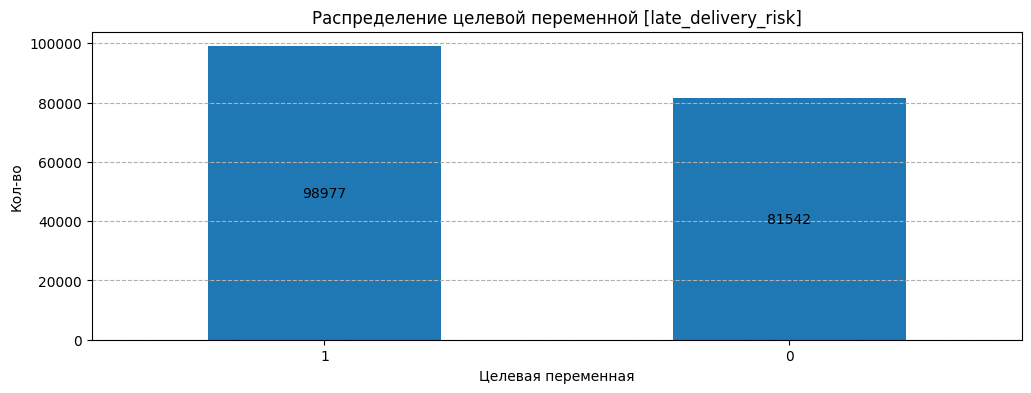

,late_delivery_risk
count,180519.00
mean,0.55
std,0.50
min,0.00
25%,0.00
50%,1.00
75%,1.00
max,1.00


In [8]:
target_name = 'late_delivery_risk'
late_delivery_risk = orders_df[target_name]

late_delivery_risk_desc = late_delivery_risk.describe()
late_delivery_risk_val_cnt = late_delivery_risk.value_counts()

ax = late_delivery_risk_val_cnt.plot(
    kind='bar',
    title=f'Распределение целевой переменной [late_delivery_risk]',
    xlabel='Целевая переменная',
    ylabel='Кол-во',
    figsize=(12, 4),
    rot=0
)

ax.bar_label(container=ax.containers[0], label_type='center')
ax.grid(axis='y', linestyle='--')

plt.show()

late_delivery_risk_desc

In [9]:
print(f"Доля доставок с задержкой: {late_delivery_risk_val_cnt.iloc[0] / late_delivery_risk_desc['count'] * 100:.1f}%")
print(f"Доля доставок без задержек: {late_delivery_risk_val_cnt.iloc[1] / late_delivery_risk_desc['count'] * 100:.1f}%")

Доля доставок с задержкой: 54.8%
Доля доставок без задержек: 45.2%


In [10]:
def show_missing_stats(df: pd.DataFrame) -> pd.DataFrame:
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]

    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [11]:
def show_features(df: pd.DataFrame) -> tuple[list, list]:
    table = []
    
    num_cols = []
    cat_cols = []
    
    for col in df.columns:
        nunique = df[col].nunique()
        
        if nunique > 10:
            num_cols.append(col)
        else:
            cat_cols.append(col)
        
        table.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': nunique,
        })
    
    display(pd.DataFrame(table).sort_values(by='Кол-во', ascending=False))
    
    return num_cols, cat_cols

In [12]:
def create_num_plot(df: pd.DataFrame, col: str, target_name: str) -> None:
    sns.set_theme(style="whitegrid")
    
    has_target = target_name in df.columns if target_name else False
    ncols = 3 if has_target else 2

    _, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
    
    sns.histplot(
        data=df, 
        x=col, 
        bins=70, 
        kde=True, 
        ax=axes[0],
    )
    axes[0].set_title(f'Распределение: {col}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Частота')

    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[1], 
        color='#A8DADC'
    )
    axes[1].set_title(f'Размах (Outliers): {col}', fontsize=14, fontweight='bold')

    if has_target:
        sns.barplot(
            data=df,
            x=target_name,
            y=col,
            alpha=0.4,
            edgecolor=None,
            ax=axes[2]
        )

        axes[2].set_title(f'Зависимость задержки доставки от {col}', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Значение признака')
        axes[2].set_ylabel('Наличие задержки')
        axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()

def show_num_plots(df: pd.DataFrame, cols: List[str], target_name: str) -> None:
    for col in cols:
        create_num_plot(df, col, target_name)

In [13]:
def create_cat_plot(df: pd.DataFrame, col: str) -> None:
    plt.figure(figsize=(12, 4))
    
    ax = sns.countplot(
        data=df,
        x=col,
        hue=col,
        legend=False,
        palette='viridis',
        dodge=False
    )
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    ax.set_title(f'Счётный график: {col}', fontsize=14, fontweight='bold')
    ax.grid(axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_cat_plots(df, cols) -> None:
    for col in cols:
        create_cat_plot(df, col)

### Анализ датафрейма: **Профили клиентов**

#### Пропуски

'Пропусков в данных нет'

Явные дубликаты строк: 0


#### Числовые признаки

,Признак,Уникальные значения,Кол-во
2,total_sales,"[472.45, 1618.66, 3189.2, 1480.71, 1101.92, 29...",12472
0,customer_lat,"[25.953648, 38.375595, 18.025375, 33.67002, 18...",11250
1,customer_lon,"[-97.50768, -104.72602, -66.61508, -112.24708,...",4487
4,avg_discount,"[0.06, 0.126, 0.105000004, 0.135, 0.14, 0.1066...",2266
6,recency,"[793, 137, 230, 381, 458, 647, 221, 127, 141, ...",1012
5,return_rate,"[0.0, 0.11764706, 0.2, 0.15, 0.33333334, 0.363...",166
3,total_orders,"[1, 4, 5, 3, 7, 8, 2, 6, 9, 13, 10, 11, 12, 14...",15


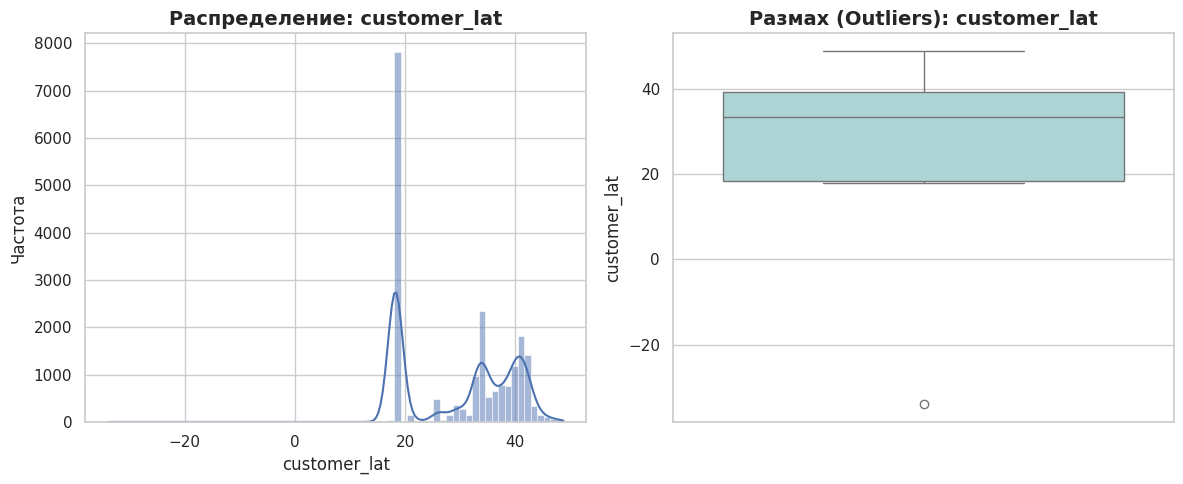

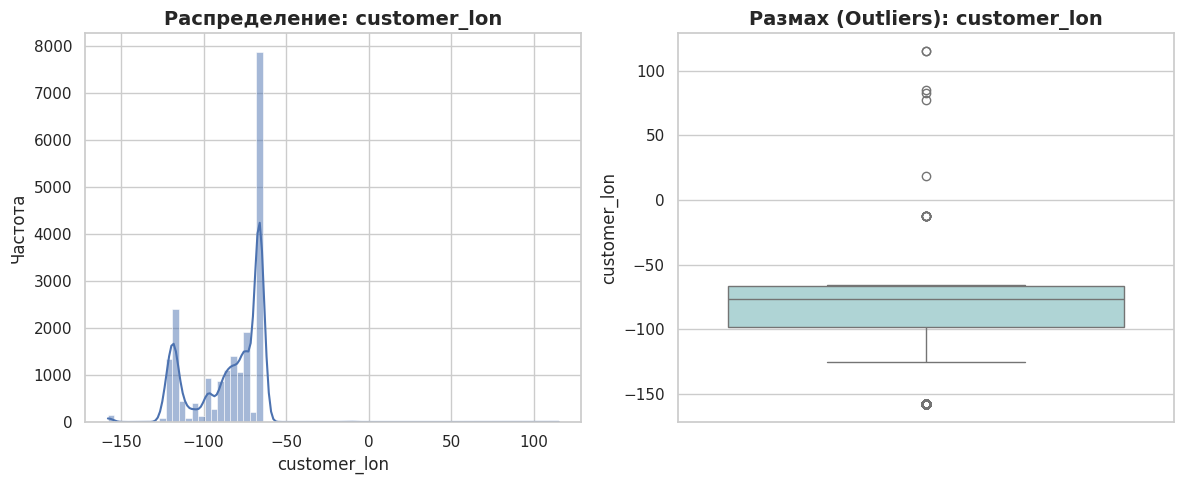

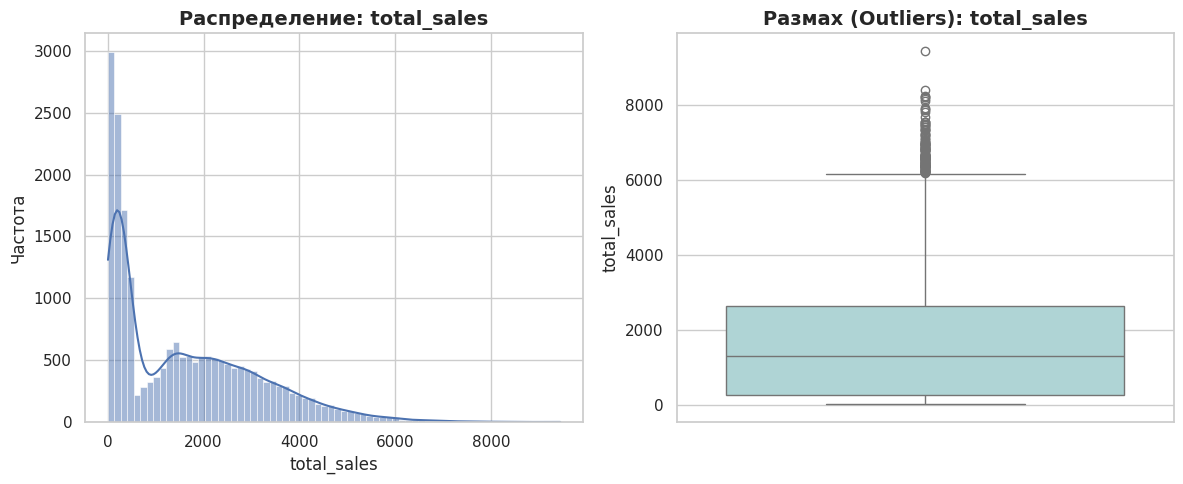

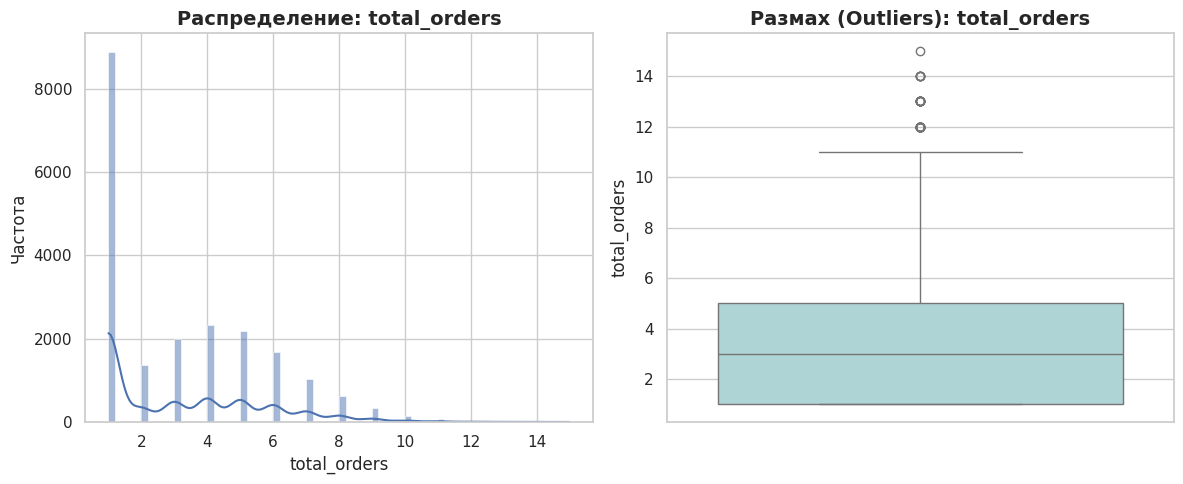

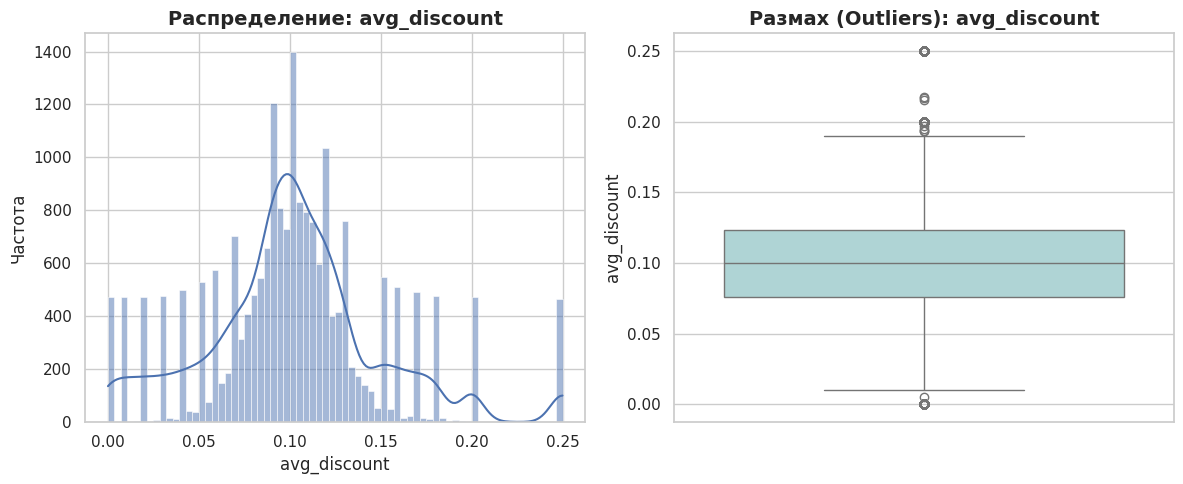

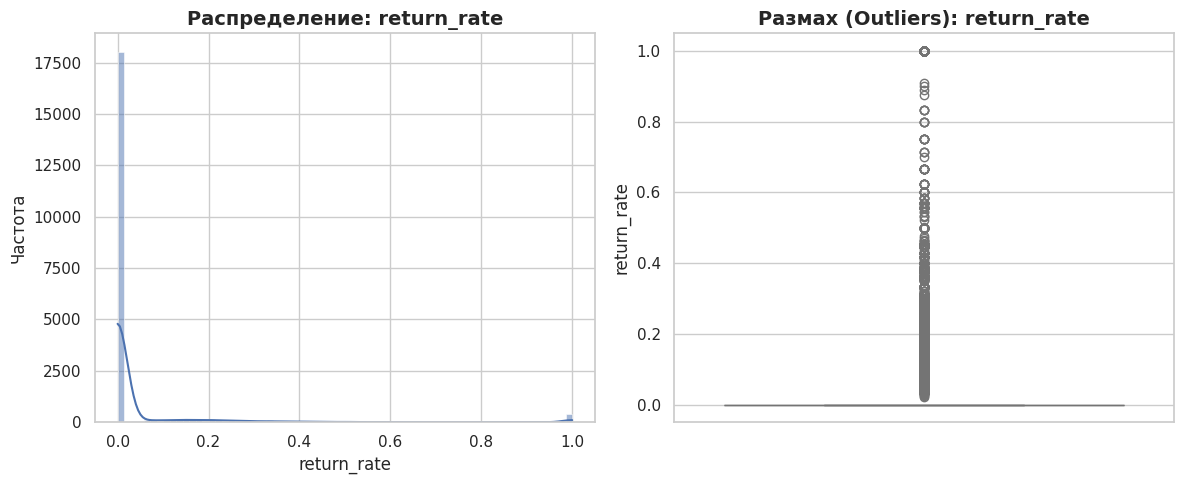

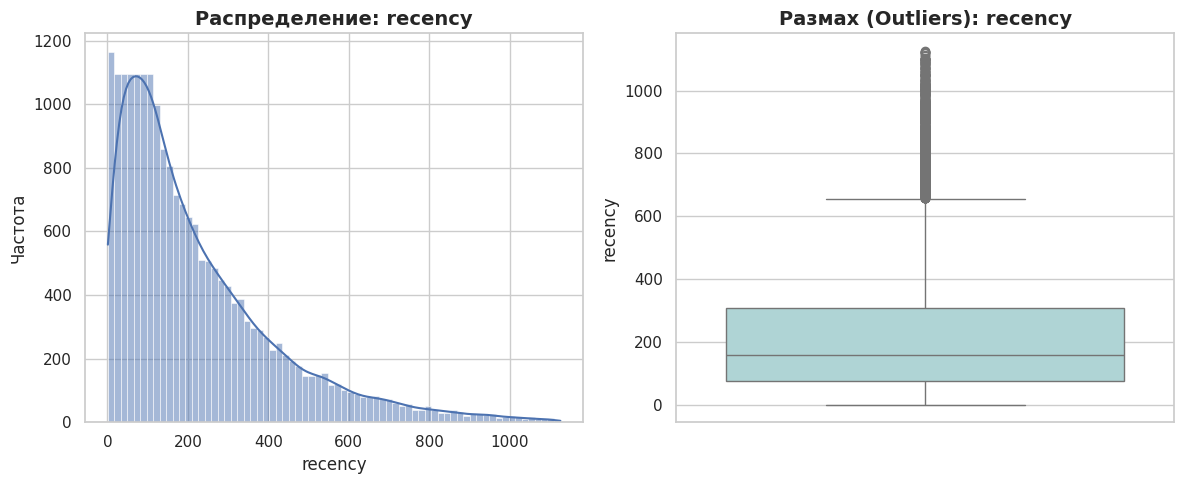

### Анализ датафрейма: **События продаж**

#### Пропуски

'Пропусков в данных нет'

Явные дубликаты строк: 0


#### Числовые признаки

,Признак,Уникальные значения,Кол-во
1,item_price,"[327.75, 59.99, 39.99, 50.0, 44.99, 54.97, 99....",75
4,order_hour,"[22, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0,...",24
2,order_month,"[1, 2, 10, 3, 11, 12, 6, 8, 4, 5, 7, 9]",12
3,order_weekday,"[2, 5, 4, 1, 6, 0, 3]",7
0,late_delivery_risk,"[0, 1]",2


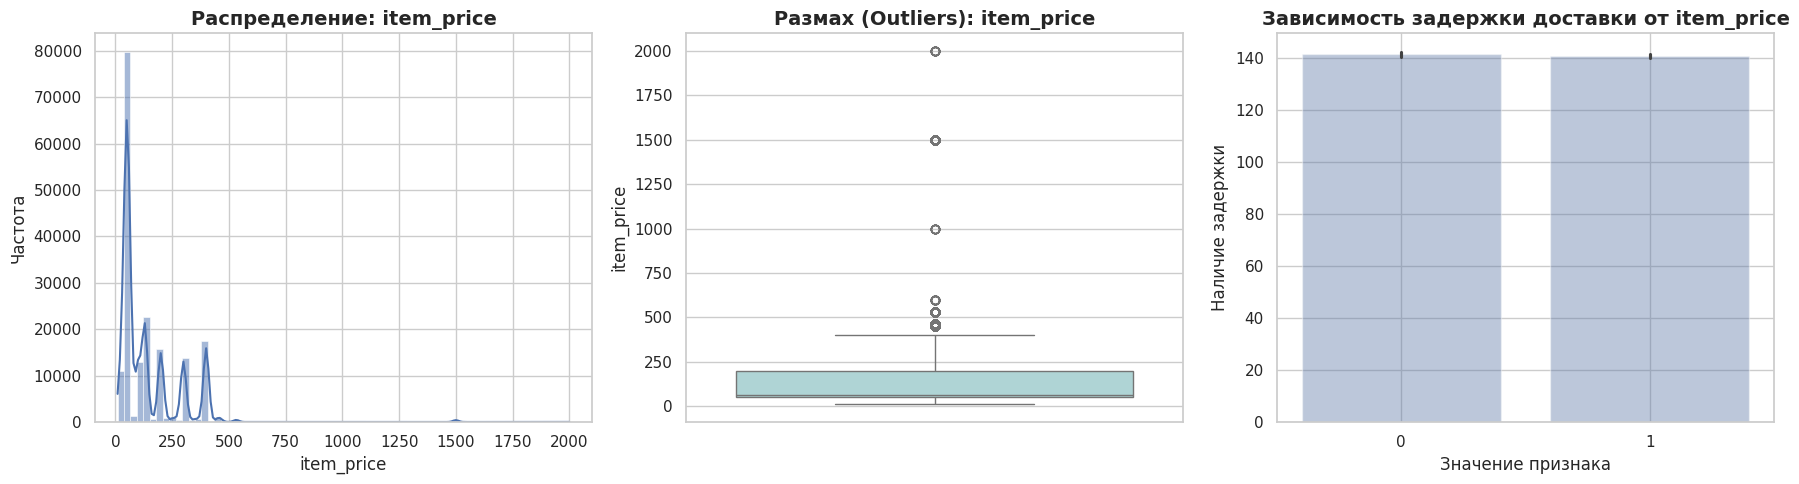

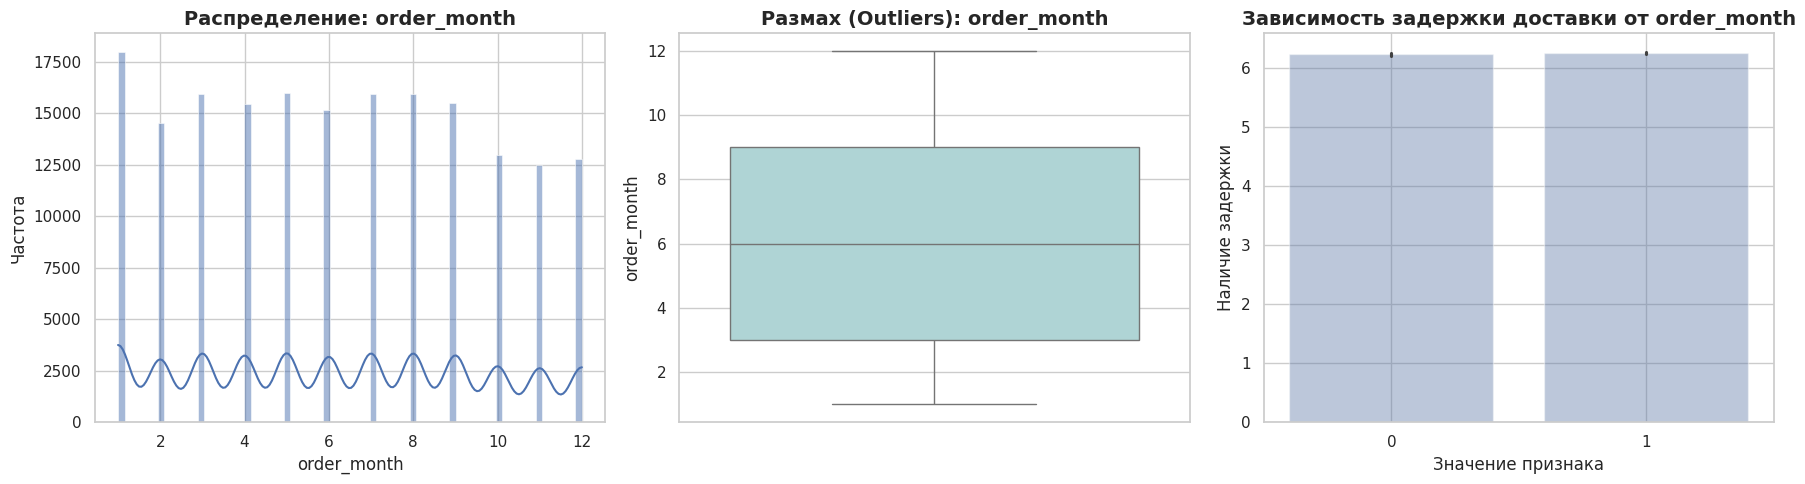

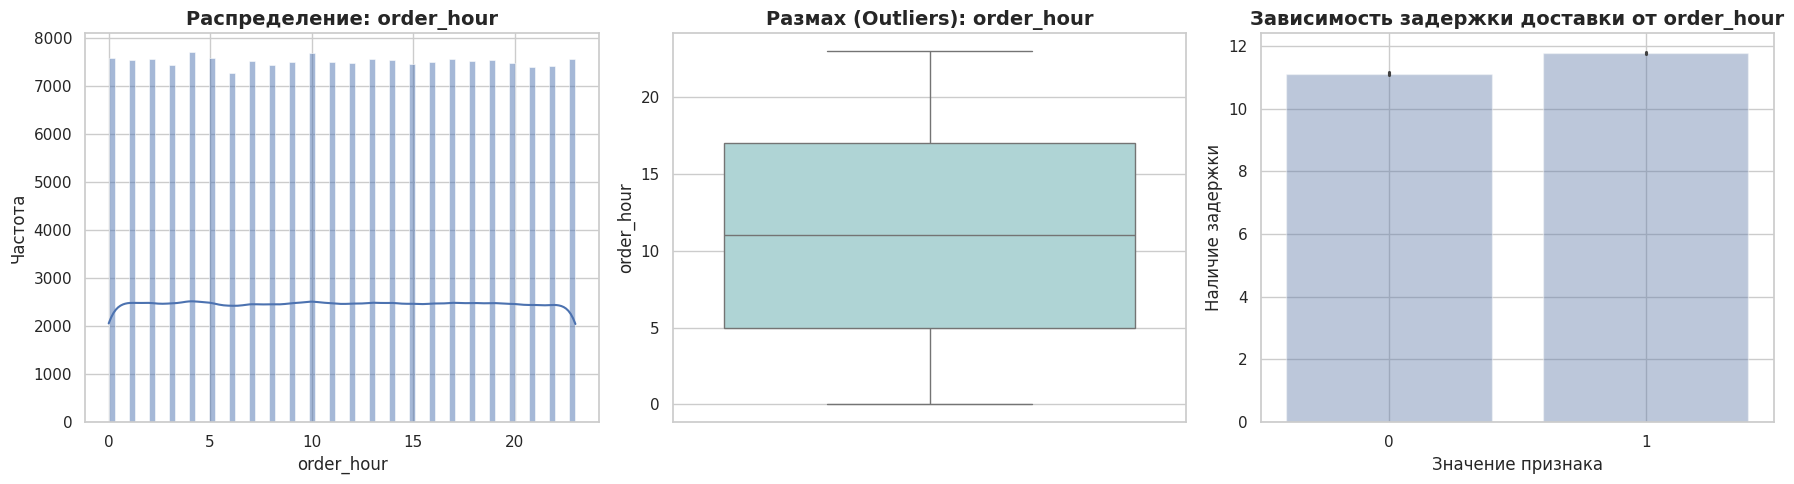

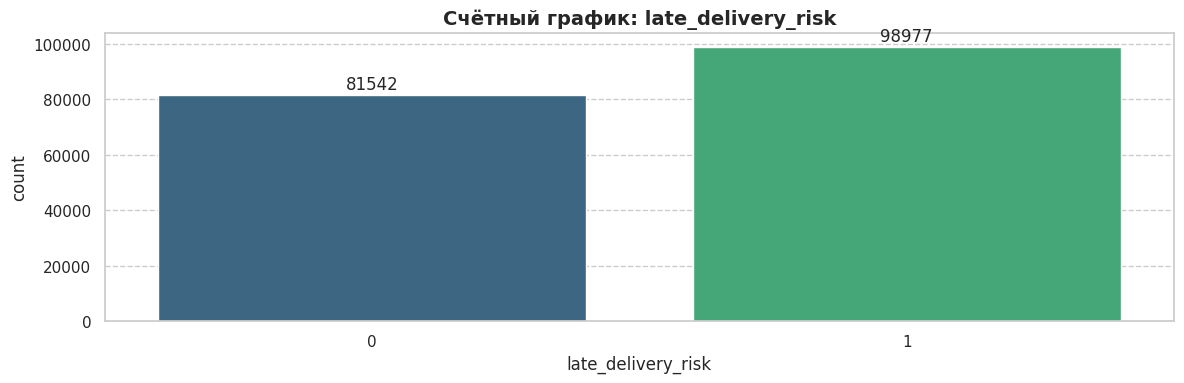

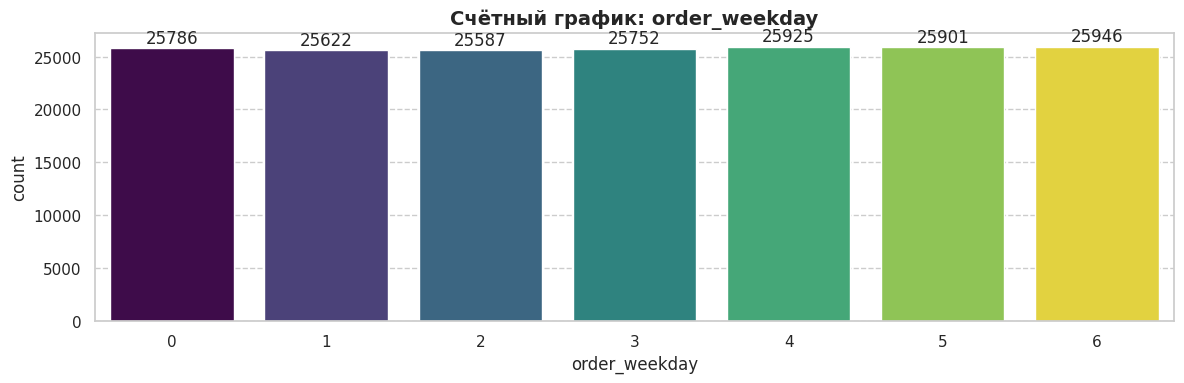

#### Категориальные признаки

,Признак,Уникальные значения,Кол-во
2,order_date,"[2018-01-31 22:56:00, 2018-01-13 12:27:00, 201...",65752
1,category_name,"[Sporting Goods, Cleats, Shop By Sport, Women'...",50
0,shipping_mode,"[Standard Class, First Class, Second Class, Sa...",4


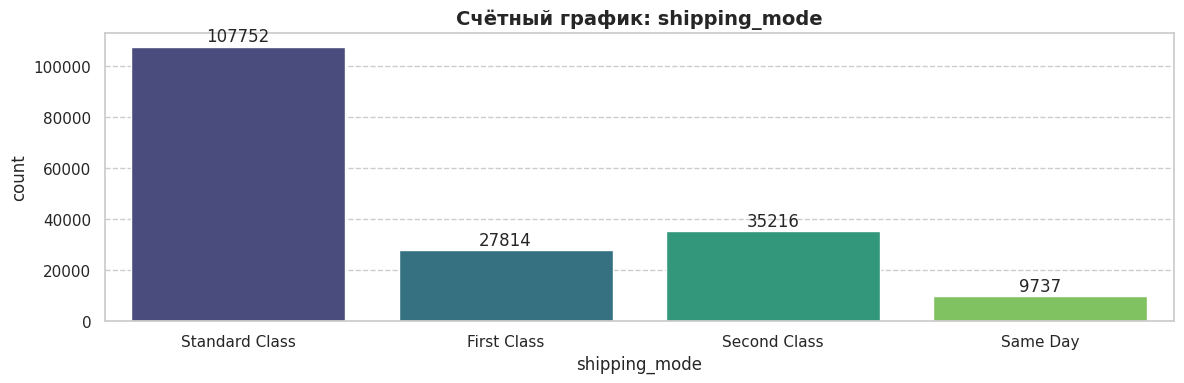

In [14]:
exclude_cols = ['customer_id', 'order_id']

def primary_analysis(
    df: pd.DataFrame, 
    name: str, 
    target_name: str, 
    exclude: List[str] = None
) -> None:
    if exclude is None:
        exclude = []
        
    display(Markdown(f'### Анализ датафрейма: **{name}**'))
    
    display(Markdown(f'#### Пропуски'))
    display(show_missing_stats(df))
    
    dup_count = df.duplicated().sum()
    print(f"Явные дубликаты строк: {dup_count}")
    
    working_df = df.drop(columns=[c for c in exclude if c in df.columns])
    
    num_cols = working_df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = working_df.select_dtypes(exclude=['number']).columns.tolist()
    
    if num_cols:
        display(Markdown(f'#### Числовые признаки'))

        n_num, n_cat = show_features(working_df[num_cols])
        show_num_plots(working_df, n_num, target_name)
        if n_cat:
            show_cat_plots(working_df, n_cat)

    if cat_cols:
        display(Markdown(f'#### Категориальные признаки'))
        _, c_cat = show_features(working_df[cat_cols])
        show_cat_plots(working_df, c_cat)

primary_analysis(customers_df, 'Профили клиентов', target_name, exclude_cols)
primary_analysis(orders_df, 'События продаж', target_name, exclude_cols)

Явных аномалий, требующих удаления, в данных не обнаружено. Выбросы в `total_sales`, `recency` и `return_rate` отражают реальную неоднородность клиентской базы и бизнесово обоснованы. Единственные записи, подлежащие удалению - географические аномалии в координатах, которые будут обработаны на следующем шаге.

---

In [15]:
lon_min = -125
lon_max = -20

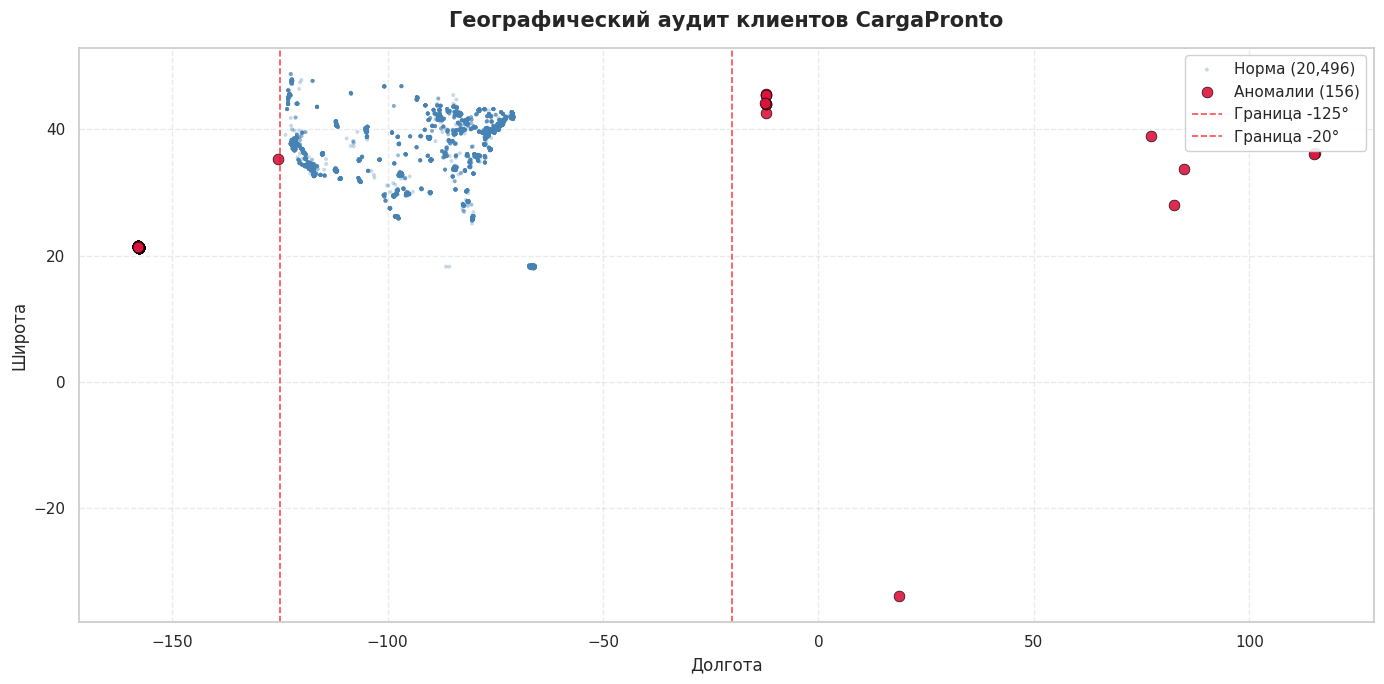

In [16]:
def show_geographical_audit(df: pd.DataFrame, lon_min: int, lon_max: int) -> None:
    _, ax = plt.subplots(figsize=(14, 7))
    
    mask_normal = (df['customer_lon'] >= lon_min) & (df['customer_lon'] <= lon_max)
    normal = df[mask_normal]
    anomaly = df[~mask_normal]
    
    ax.scatter(normal['customer_lon'], normal['customer_lat'],
               alpha=0.3, s=8, color='steelblue', edgecolors='none', label=f'Норма ({len(normal):,})')
    
    ax.scatter(anomaly['customer_lon'], anomaly['customer_lat'],
               alpha=0.9, s=60, color='crimson', edgecolors='black', 
               linewidths=0.5, zorder=5, label=f'Аномалии ({len(anomaly):,})')
    
    ax.axvline(x=lon_min, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Граница {lon_min}°')
    ax.axvline(x=lon_max, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Граница {lon_max}°')
    
    ax.set_title('Географический аудит клиентов CargaPronto', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Долгота', fontsize=12)
    ax.set_ylabel('Широта', fontsize=12)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

show_geographical_audit(customers_df, lon_min, lon_max)

In [17]:
init_customers_len = len(customers_df)
init_orders_len = len(orders_df)

In [18]:
mask_normal = (customers_df['customer_lon'] >= lon_min) & (customers_df['customer_lon'] <= lon_max)
anomaly_ids = customers_df.loc[~mask_normal, 'customer_id']

customers_df = customers_df[~customers_df['customer_id'].isin(anomaly_ids)]
orders_df = orders_df[~orders_df['customer_id'].isin(anomaly_ids)]

In [19]:
upd_customers_len = len(customers_df)
upd_orders_len = len(orders_df)

In [20]:
print(f"Число строк до удаления выбросов [customers_df]: {init_customers_len}")
print(f"Число строк до удаления выбросов [orders_df]: {init_orders_len}")

print(f"Число строк после удаления выбросов [customers_df]: {upd_customers_len}")
print(f"Число строк после удаления выбросов [orders_df]: {upd_orders_len}")

print(f"Дельта [customers_df]: {init_customers_len - upd_customers_len} | {(upd_customers_len - init_customers_len) / init_customers_len * 100:.2}%")
print(f"Дельта [orders_df]: {init_orders_len - upd_orders_len} | {(upd_orders_len - init_orders_len) / init_orders_len * 100:.2}%")

Число строк до удаления выбросов [customers_df]: 20652
Число строк до удаления выбросов [orders_df]: 180519
Число строк после удаления выбросов [customers_df]: 20496
Число строк после удаления выбросов [orders_df]: 179089
Дельта [customers_df]: 156 | -0.76%
Дельта [orders_df]: 1430 | -0.79%


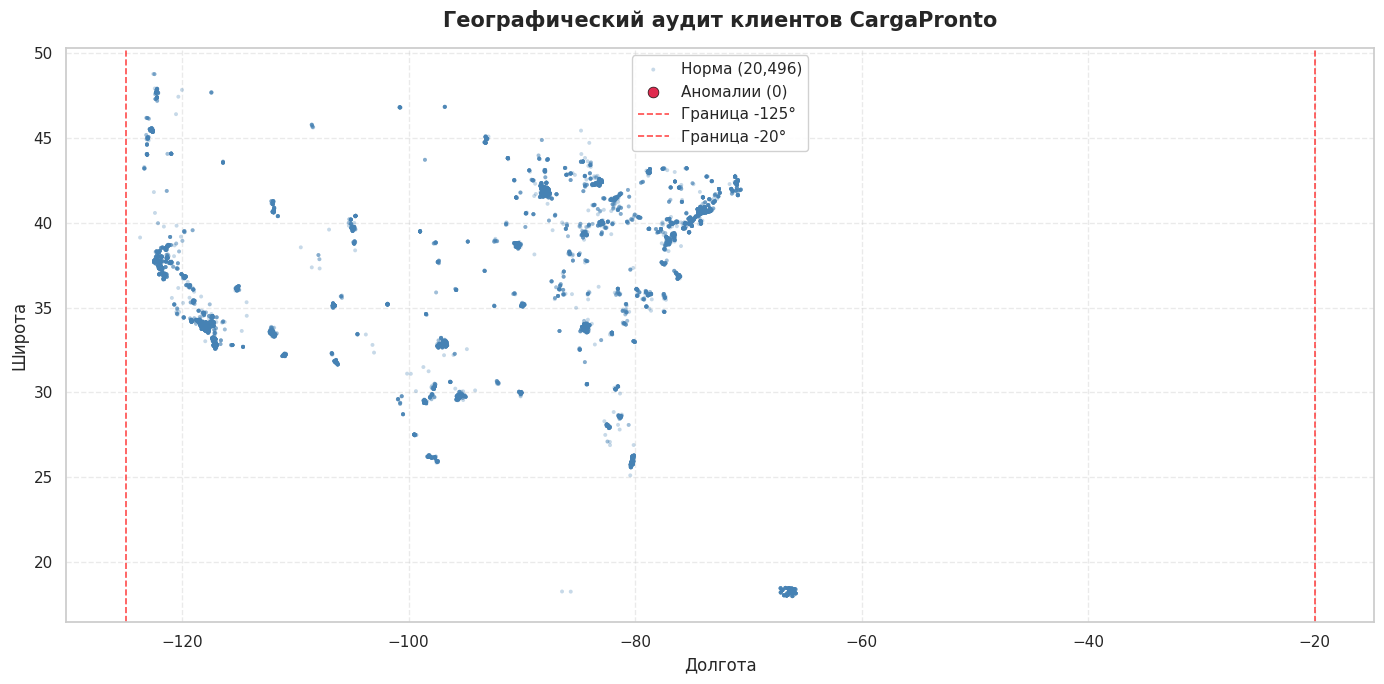

In [21]:
show_geographical_audit(customers_df, lon_min, lon_max)

---

In [22]:
corr_df = orders_df.drop(columns=['order_id', 'customer_id', 'order_date'])

In [23]:
def show_heatmap(
    corr: pd.DataFrame, 
    title: str, 
    x: int,
    y_coef: float
) -> None:
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))
    
    sns.heatmap(
        corr, 
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )

    plt.title(title)
    plt.show()

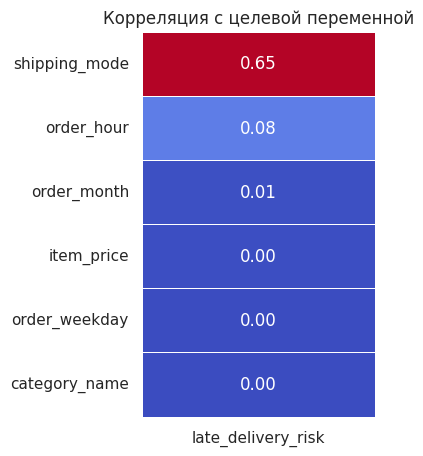

In [24]:
corr_matrix = corr_df.phik_matrix(interval_cols=['item_price'])
target_corr = corr_matrix[corr_matrix.index != 'late_delivery_risk'][['late_delivery_risk']].sort_values(by='late_delivery_risk', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

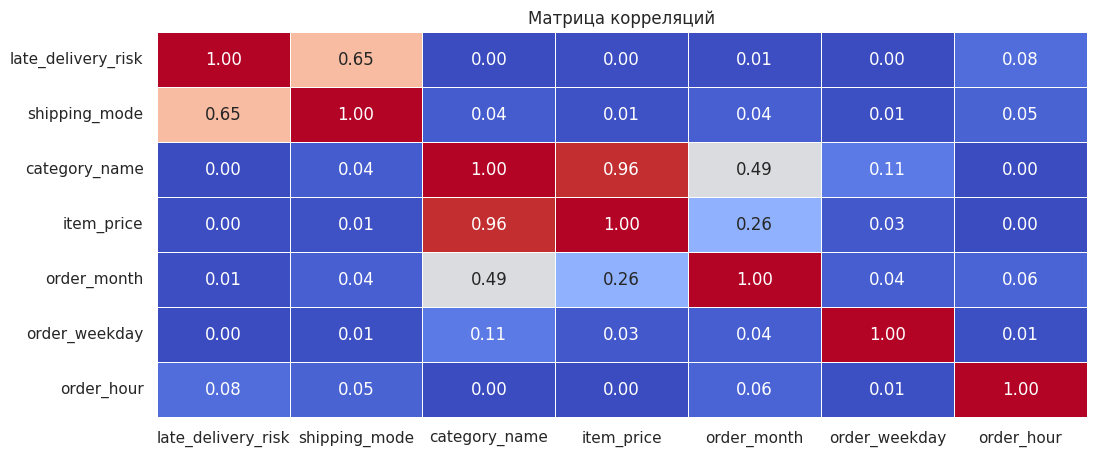

In [25]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=12, y_coef=.5)

Вывод:

В ходе EDA пропусков и дубликатов в обоих датасетах выявлено не было. Распределения числовых признаков имеют правосторонние хвосты - выбросы в `total_sales`, `recency` и `return_rate` бизнесово обоснованы и удалению не подлежат. Баланс классов умеренный (45/55), балансировка не требуется. Единственным значимым признаком по корреляции с таргетом оказался `shipping_mode` (0.65), тогда как `item_price` и `category_name` линейной связи с целевой переменной не показали. Географический аудит выявил 156 аномальных клиентов за пределами рабочего региона, после удаления которых датасет клиентов сократился на 0.76% (20 652 -> 20 496), а заказов - на 0.79% (180 519 -> 179 089). Потери данных минимальны и на качество модели не повлияют.

## Моделирование

In [26]:
groups = orders_df['customer_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_val_idx, test_idx = next(gss.split(orders_df, groups=groups))

df_train_val = orders_df.iloc[train_val_idx]
train_val_groups = df_train_val['customer_id']

train_idx, val_idx = next(gss.split(df_train_val, groups=train_val_groups))

df_train: pd.DataFrame = df_train_val.iloc[train_idx]
X_train = df_train.drop(columns=['late_delivery_risk'])
y_train = df_train['late_delivery_risk']
print(f"Размер всего обучающего датасета: X_train={X_train.shape}; y_train={len(y_train)}")

df_val: pd.DataFrame = df_train_val.iloc[val_idx]
X_val = df_val.drop(columns=['late_delivery_risk'])
y_val = df_val['late_delivery_risk']
print(f"Размер валидации: X_val={X_val.shape}; y_val={len(y_val)}")

df_test: pd.DataFrame = orders_df.iloc[test_idx]
X_test = df_test.drop(columns=['late_delivery_risk'])
y_test = df_test['late_delivery_risk']
print(f"Размер теста: X_test={X_test.shape}; y_test={len(y_test)}")

train_ids = set(df_train['customer_id'])
val_ids = set(df_val['customer_id'])
test_ids = set(df_test['customer_id'])

assert len(train_ids & val_ids) == 0, "Пересечение train и val"
assert len(train_ids & test_ids) == 0, "Пересечение train и test"
assert len(val_ids & test_ids) == 0, "Пересечение val и test"

print("Пересечений нет - разбивка корректна")

Размер всего обучающего датасета: X_train=(114777, 9); y_train=114777
Размер валидации: X_val=(28300, 9); y_val=28300
Размер теста: X_test=(36012, 9); y_test=36012
Пересечений нет - разбивка корректна


In [27]:
useless_cols = exclude_cols + ['order_date', 'late_delivery_risk']

num_cols = [col for col in orders_df.select_dtypes(include='number').columns \
    if col not in useless_cols]

cat_col_ohe = ['shipping_mode']
cat_col_target = ['category_name']

selected_features = num_cols + cat_col_ohe + cat_col_target

In [28]:
def make_preprocessor(num_cols: List[str], cat_col_ohe: List[str], cat_col_target: List[str]):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat_ohe', OneHotEncoder(drop='first'), cat_col_ohe),
            ('cat_target', TargetEncoder(), cat_col_target),
        ],
        remainder='drop'
    )

In [29]:
results = []

In [30]:
def show_ROC_curve(y_true, y_proba, score, name, ax):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {score:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')
    ax.set_title(f'ROC-кривая: {name}')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

def plot_classification_results(y_true, y_proba, y_pred, thresh, roc_auc, name="Model"):
    _, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set(
        title=f"{name} - Confusion Matrix",
        xlabel="Предсказанные метки",
        ylabel="Актуальные метки"
    )

    df_probs = pd.DataFrame({'Probability': y_proba, 'Actual': y_true})

    sns.histplot(data=df_probs, x='Probability', hue='Actual',
                 element='step', kde=True, bins=30, ax=ax2, palette='magma')

    ax2.axvline(thresh, color="red", linestyle="--", label=f'Порог {thresh:.2f}')
    ax2.set(
        title=f"{name} - Вероятностное распределение по классам",
        xlabel="Предполагаемая вероятность (1)",
        ylabel="Кол-во",
    )
    ax2.legend(loc='upper left')
    
    show_ROC_curve(y_true, y_proba, roc_auc, name, ax3)

    plt.tight_layout()
    plt.show()

def evaluate_model(
    pipeline: Pipeline, 
    X_train: pd.DataFrame, y_train: pd.DataFrame,
    X_test: pd.DataFrame, y_test: pd.DataFrame, 
    name: str,
    params: dict=None
) -> float:
    pipeline.fit(X_train, y_train, **(params or {}))
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_proba)
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    optimal_idx = (tpr - fpr).argmax()
    threshold = thresholds[optimal_idx] 

    y_pred = (y_proba >= threshold).astype(int)

    print("Итоговые метрики:")
    print(classification_report(y_test, y_pred, zero_division=0))
    plot_classification_results(y_test, y_proba, y_pred, threshold, roc_auc, name=name)

    data = {
        'name': name,
        'roc_auc': roc_auc,
        'threshold': threshold
    }

    display(pd.DataFrame([data]))
    results.append(data)
    
    return threshold

In [31]:
def run_optuna(build_pipeline_fn, X_train, y_train, X_val, y_val, name):
    def objective(trial):
        pipeline, fit_params = build_pipeline_fn(trial)

        pipeline.fit(X_train, y_train, **fit_params)
        y_proba = pipeline.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_proba)
    
        return roc_auc

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=20, show_progress_bar=True, n_jobs=1)
    
    fig1 = optuna.visualization.plot_optimization_history(study)
    fig2 = optuna.visualization.plot_param_importances(study)
    
    display(fig1)
    display(fig2)

    best_params = study.best_params
    print("Лучшие гиперпараметры:", best_params)
    best_value = study.best_value
    print("Лучшее значение roc_auc на валидационной выборке:", best_value)

    pipeline, fit_params = build_pipeline_fn(best_params, isFinal=True)
    threshold = evaluate_model(pipeline, X_train, y_train, X_val, y_val, name, fit_params)

    return best_params, threshold

In [32]:
def get_base_pipeline(preprocessor, model):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

def execute_run(
    model, 
    get_params, 
    fixed_params, 
    model_name, 
    X_train, y_train,
    X_val, y_val,
    preprocessor=None, 
    fit_params=None,
):
    fit_params = fit_params or {}
    
    def build_pipeline_fn(trial, isFinal=False):
        params = trial if isFinal else get_params(trial)
        model_inst = model(**params, **fixed_params)
        
        pipeline = model_inst if preprocessor is None \
                    else get_base_pipeline(preprocessor, model_inst)

        return pipeline, fit_params

    best_params, threshold = run_optuna(
        build_pipeline_fn, 
        X_train, 
        y_train, 
        X_val, 
        y_val, 
        model_name
    )

    return best_params, threshold

[I 2026-04-20 19:43:14,268] A new study created in memory with name: no-name-2e7d1f98-4eb1-4fa7-9759-94ef1277c28c


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-20 19:43:19,615] Trial 0 finished with value: 0.7298749516152125 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.7298749516152125.
[I 2026-04-20 19:43:20,342] Trial 1 finished with value: 0.7296382505806969 and parameters: {'class_weight': 'balanced', 'tol': 0.004622589001020831, 'max_iter': 5822, 'solver': 'saga', 'C': 0.039054412752107935, 'l1_ratio': 0.2912291401980419}. Best is trial 0 with value: 0.7298749516152125.
[I 2026-04-20 19:43:20,747] Trial 2 finished with value: 0.7299569150886291 and parameters: {'class_weight': None, 'tol': 0.0003839629299804173, 'max_iter': 8594, 'solver': 'newton-cg', 'C': 0.35849855803404745}. Best is trial 2 with value: 0.7299569150886291.
[I 2026-04-20 19:43:21,166] Trial 3 finished with value: 0.7117810964717594 and parameters: {'class_weight': 'balanced', 'tol': 0.00021930485556643703,

Лучшие гиперпараметры: {'class_weight': None, 'tol': 0.0019318807255899724, 'max_iter': 13352, 'solver': 'newton-cholesky', 'C': 20.829087820407633}
Лучшее значение roc_auc на валидационной выборке: 0.7300482191719007
Итоговые метрики:
              precision    recall  f1-score   support

           0       0.63      0.88      0.74     12793
           1       0.86      0.58      0.69     15507

    accuracy                           0.72     28300
   macro avg       0.75      0.73      0.72     28300
weighted avg       0.76      0.72      0.71     28300



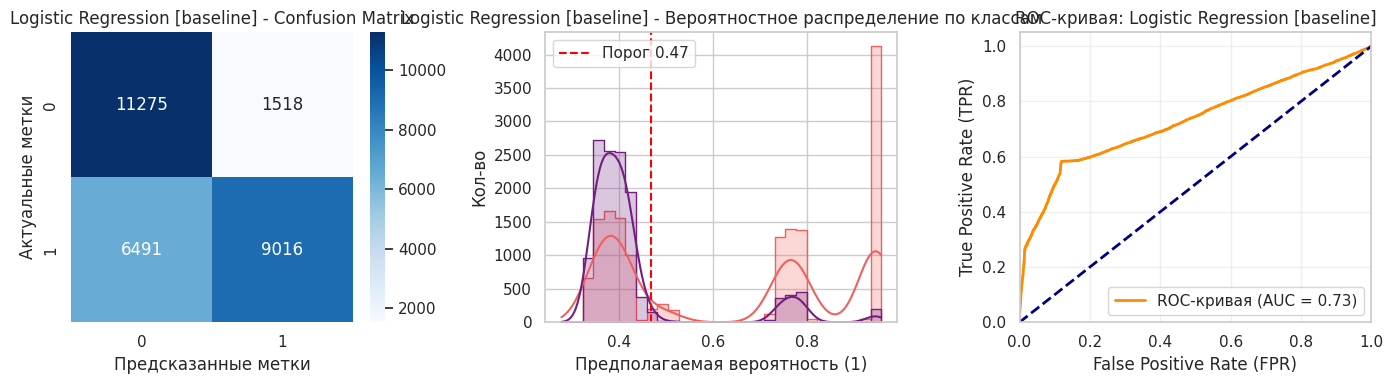

,name,roc_auc,threshold
0,Logistic Regression [baseline],0.73,0.47


CPU times: user 25.5 s, sys: 521 ms, total: 26 s
Wall time: 23.2 s


In [33]:
%%time

def run_log_reg(
    name: str, 
    X_train, y_train,
    X_val, y_val,
    num_cols, cat_col_ohe, cat_col_target
):
    def get_params(trial):
        params = {
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
            "max_iter": trial.suggest_int("max_iter", 2000, 20000),
            "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
            "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        }

        solver = params["solver"]
        if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
            params["l1_ratio"] = 0
        elif solver == "saga":
            params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
        
        return params

    fixed_params = {
        "fit_intercept": True,
        "random_state": RANDOM_STATE,
    }

    preprocessor = make_preprocessor(num_cols, cat_col_ohe, cat_col_target)

    return execute_run(
            LogisticRegression,
            get_params, fixed_params,
            name,
            X_train, y_train,
            X_val, y_val,
            preprocessor
        )

lr_best_params, lr_threshold = \
    run_log_reg(
        "Logistic Regression [baseline]",
        X_train, y_train,
        X_val, y_val,
        num_cols, cat_col_ohe, cat_col_target
    )

[I 2026-04-20 19:43:37,760] A new study created in memory with name: no-name-e45429b7-4021-4d01-9a50-f140e8d03cb8


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-20 19:43:42,389] Trial 0 finished with value: 0.7531328105525563 and parameters: {'iterations': 62, 'depth': 8, 'learning_rate': 0.05395030966670229, 'l2_leaf_reg': 3.968793330444372}. Best is trial 0 with value: 0.7531328105525563.
[I 2026-04-20 19:43:44,602] Trial 1 finished with value: 0.7424902593141317 and parameters: {'iterations': 31, 'depth': 3, 'learning_rate': 0.011430983876313222, 'l2_leaf_reg': 7.348118405270449}. Best is trial 0 with value: 0.7531328105525563.
[I 2026-04-20 19:43:49,479] Trial 2 finished with value: 0.7589313910833148 and parameters: {'iterations': 94, 'depth': 7, 'learning_rate': 0.010485387725194618, 'l2_leaf_reg': 9.330606024425668}. Best is trial 2 with value: 0.7589313910833148.
[I 2026-04-20 19:43:54,008] Trial 3 finished with value: 0.7573150799569057 and parameters: {'iterations': 127, 'depth': 4, 'learning_rate': 0.015199348301309814, 'l2_leaf_reg': 1.5254729458052607}. Best is trial 2 with value: 0.7589313910833148.
[I 2026-04-20 19:43

Лучшие гиперпараметры: {'iterations': 15, 'depth': 6, 'learning_rate': 0.02889932454345509, 'l2_leaf_reg': 2.081067898791295}
Лучшее значение roc_auc на валидационной выборке: 0.7602267290135488
Итоговые метрики:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74     12793
           1       0.86      0.58      0.69     15507

    accuracy                           0.72     28300
   macro avg       0.75      0.73      0.72     28300
weighted avg       0.76      0.72      0.71     28300



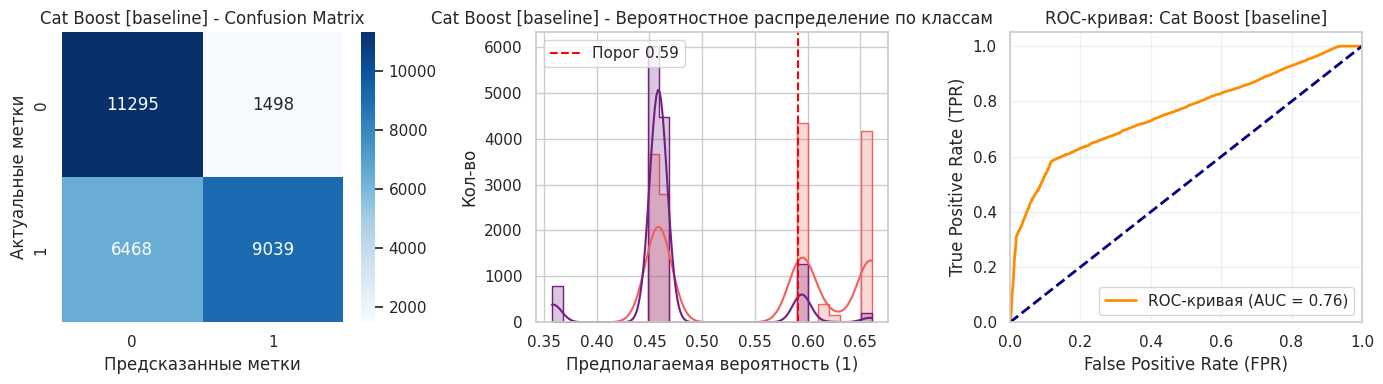

,name,roc_auc,threshold
0,Cat Boost [baseline],0.76,0.59


CPU times: user 1min 36s, sys: 5.28 s, total: 1min 41s
Wall time: 1min 6s


In [34]:
%%time

cb_fixed_params = {
    "random_state": RANDOM_STATE,
    "thread_count": -1,
    "verbose": 0,
}

def run_catboost(
    name: str, 
    X_train, y_train,
    X_val, y_val,
    cb_fixed_params,
    selected_features=None, 
    cat_features=None
):
    selected_features = selected_features or globals()['selected_features']
    cat_features = cat_features or (cat_col_ohe + cat_col_target)

    def get_params(trial):
        return {
            "iterations": trial.suggest_int("iterations", 10, 150),
            "depth": trial.suggest_int("depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        }

    cb_fixed_fit_params = {
        'cat_features': cat_features,
    }

    return execute_run(
            CatBoostClassifier, 
            get_params, cb_fixed_params, 
            name, 
            X_train[selected_features], y_train,
            X_val[selected_features], y_val, 
            fit_params=cb_fixed_fit_params
        )

cb_best_params, cb_threshold = \
    run_catboost(
        "Cat Boost [baseline]",
        X_train, y_train,
        X_val, y_val,
        cb_fixed_params,
    )

In [35]:
def show_results(results: list):
    df = pd.DataFrame(results).sort_values(by='roc_auc', ascending=False)
    display(df.style
            .background_gradient(cmap='coolwarm', subset=['roc_auc'])
            .format({'roc_auc': '{:.4f}', 'threshold': '{:.4f}'}))
    
show_results(results)

,name,roc_auc,threshold
1,Cat Boost [baseline],0.7602,0.5909
0,Logistic Regression [baseline],0.7301,0.4678


---

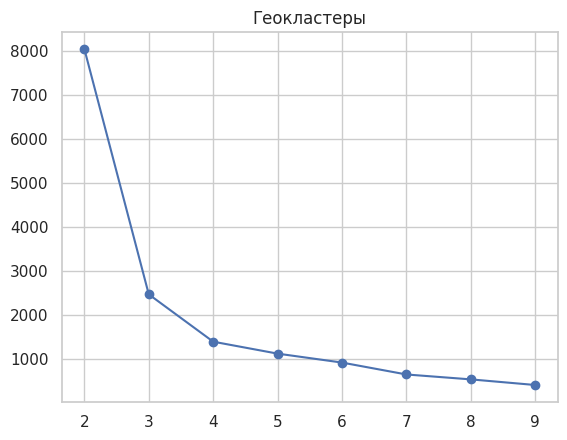

In [36]:
geo_features = ['customer_lat', 'customer_lon']
train_customer_ids = set(df_train['customer_id'])
customers_train = customers_df[customers_df['customer_id'].isin(train_customer_ids)]

scaler_geo = StandardScaler()
geo_scaled_train = scaler_geo.fit_transform(customers_train[geo_features])

inertias = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE)
    kmeans.fit(geo_scaled_train)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title('Геокластеры')
plt.show()

Между 3 и 4 ещё есть заметный перегиб (падение с ~2400 до ~1300), а после 4 кривая уже сглаживается и прирост от добавления кластера становится минимальным. 

In [37]:
K_GEO = 4

In [38]:
geo_kmeans = KMeans(n_clusters=K_GEO, init='k-means++', random_state=RANDOM_STATE)
geo_kmeans.fit(geo_scaled_train)

geo_scaled_all = scaler_geo.transform(customers_df[geo_features])
customers_df['geo_cluster'] = geo_kmeans.predict(geo_scaled_all)

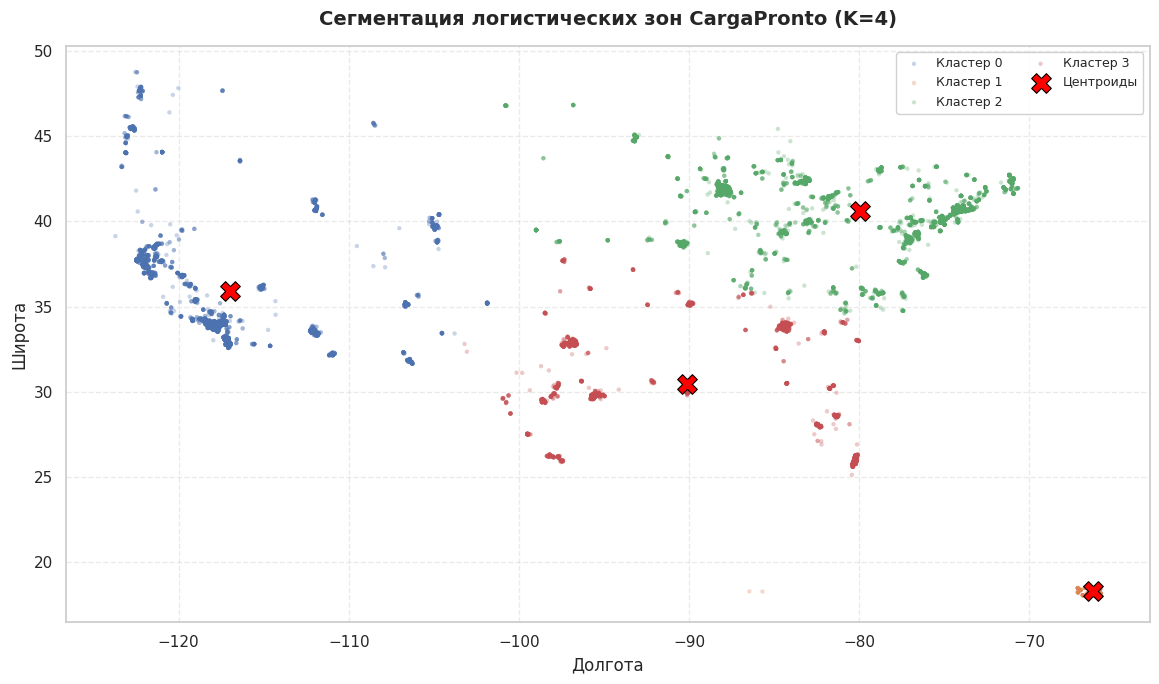

In [39]:
def plot_geo_clusters(customers_df, kmeans_model, scaler, K):
    _, ax = plt.subplots(figsize=(14, 7))
    
    for cluster_id in range(K):
        subset = customers_df[customers_df['geo_cluster'] == cluster_id]
        ax.scatter(
            subset['customer_lon'], subset['customer_lat'],
            alpha=0.3, s=10,
            edgecolors='none', label=f'Кластер {cluster_id}'
        )
    
    centroids_scaled = kmeans_model.cluster_centers_
    centroids = scaler.inverse_transform(centroids_scaled)
    ax.scatter(
        centroids[:, 1], centroids[:, 0],
        marker='X', s=200, color='red',
        edgecolors='black', linewidths=0.8,
        label='Центроиды'
    )
    
    ax.set_title(f'Сегментация логистических зон CargaPronto (K={K})', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Долгота', fontsize=12)
    ax.set_ylabel('Широта', fontsize=12)
    ax.legend(fontsize=9, framealpha=0.9, ncol=2)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

plot_geo_clusters(customers_df, geo_kmeans, scaler_geo, K_GEO)

---

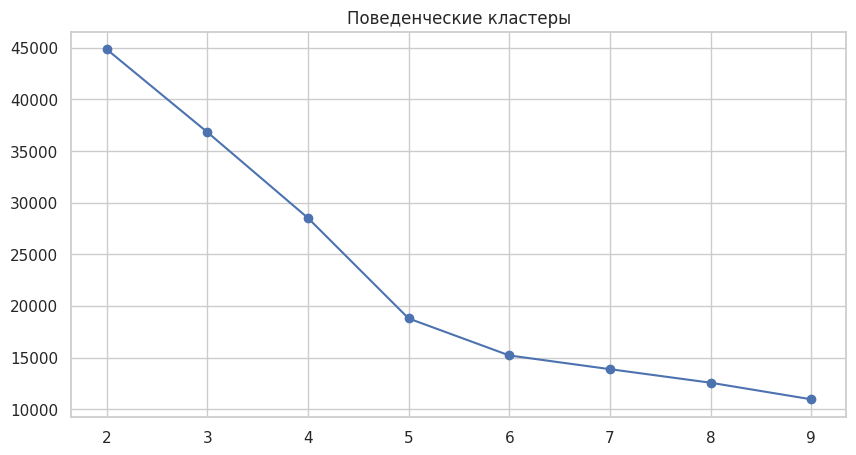

In [40]:
rfm_features = ['recency', 'total_orders', 'total_sales', 'avg_discount', 'return_rate']

scaler_rfm = StandardScaler()
rfm_scaled_train = scaler_rfm.fit_transform(customers_train[rfm_features])

inertias = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=RANDOM_STATE)
    kmeans.fit(rfm_scaled_train)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o')
plt.title('Поведенческие кластеры')
plt.show()

Между 5 и 6 виден заметный перегиб, после которого кривая заметно сглаживается.

In [41]:
K_RFM = 6

In [42]:
rfm_kmeans = KMeans(n_clusters=K_RFM, init='k-means++', random_state=RANDOM_STATE)
rfm_kmeans.fit(rfm_scaled_train)

rfm_scaled_all = scaler_rfm.transform(customers_df[rfm_features])
customers_df['beh_cluster'] = rfm_kmeans.predict(rfm_scaled_all)

In [43]:
cluster_stats = customers_df.groupby('beh_cluster')[rfm_features].mean().round(2)
cluster_stats

,recency,total_orders,total_sales,avg_discount,return_rate
beh_cluster,,,,,
0,241.00,7.25,4152.89,0.10,0.04
1,70.58,1.04,313.19,0.05,0.00
2,646.52,2.71,1391.63,0.10,0.02
3,71.98,1.05,276.39,0.17,0.00
4,158.88,1.37,517.00,0.10,0.92
5,264.27,4.23,2171.91,0.10,0.04


Кластер 1 - "Новички": низкий recency (71 дней), но всего 1 заказ и минимальная выручка (313). Недавно пришли, но ещё не стали постоянными.

Кластер 0 - "Уходящие": высокий recency (646 дня) - давно не заказывали, при этом средняя выручка. Риск потери клиента.

Кластер 2 - "Активные VIP": максимальное количество заказов (7.25) и самая высокая выручка (4152.89), recency умеренный. Самый ценный сегмент.

Кластер 4 - "Проблемные": аномально высокий return_rate (0.92) - почти все заказы возвращаются или отменяются. Потенциально высокий риск задержки.

Кластеры 3 и 5 - промежуточные группы с умеренными показателями, существенно не выделяются.

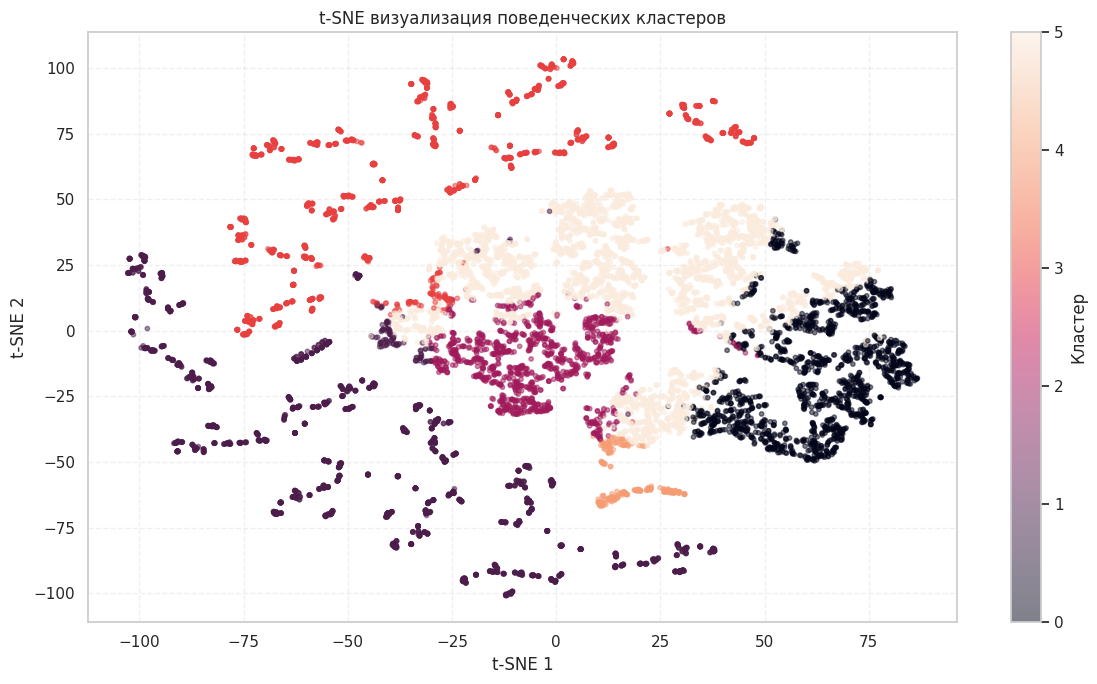

In [44]:
sample_idx = customers_df.sample(n=10000, random_state=RANDOM_STATE).index
positional_idx = customers_df.index.get_indexer(sample_idx)
rfm_scaled_sample = rfm_scaled_all[positional_idx]
labels_sample = customers_df.loc[sample_idx, 'beh_cluster']

tsne = TSNE(n_components=2, perplexity=30, init='pca', random_state=RANDOM_STATE, n_jobs=-1)
tsne_result = tsne.fit_transform(rfm_scaled_sample)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    tsne_result[:, 0], tsne_result[:, 1],
    c=labels_sample,
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Кластер')
plt.title('t-SNE визуализация поведенческих кластеров')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Кластеризация выделила два действительно уникальных сегмента - проблемных клиентов и уходящих. Остальные четыре кластера представляют собой континуум похожих профилей. Это нормальная ситуация для RFM-анализа и не является ошибкой - модель всё равно сможет извлечь пользу из меток кластеров как признаков.

In [45]:
cluster_cols = customers_df[['customer_id', 'geo_cluster', 'beh_cluster']]
upd_X_train = X_train.merge(cluster_cols, on='customer_id', how='left')
upd_X_val = X_val.merge(cluster_cols, on='customer_id', how='left')
upd_X_test = X_test.merge(cluster_cols, on='customer_id', how='left')

print(f"upd_X_train={upd_X_train.shape} | Дубликаты={upd_X_train.duplicated().sum()} | Пропуски:\n{upd_X_train.isna().sum()}")
print(f"upd_X_val={upd_X_val.shape} | Дубликаты={upd_X_val.duplicated().sum()} | Пропуски:\n{upd_X_val.isna().sum()}")
print(f"upd_X_test={upd_X_test.shape} | Дубликаты={upd_X_test.duplicated().sum()} | Пропуски:\n{upd_X_test.isna().sum()}")

upd_X_train=(114777, 11) | Дубликаты=0 | Пропуски:
order_id         0
customer_id      0
shipping_mode    0
category_name    0
order_date       0
item_price       0
order_month      0
order_weekday    0
order_hour       0
geo_cluster      0
beh_cluster      0
dtype: int64
upd_X_val=(28300, 11) | Дубликаты=0 | Пропуски:
order_id         0
customer_id      0
shipping_mode    0
category_name    0
order_date       0
item_price       0
order_month      0
order_weekday    0
order_hour       0
geo_cluster      0
beh_cluster      0
dtype: int64
upd_X_test=(36012, 11) | Дубликаты=0 | Пропуски:
order_id         0
customer_id      0
shipping_mode    0
category_name    0
order_date       0
item_price       0
order_month      0
order_weekday    0
order_hour       0
geo_cluster      0
beh_cluster      0
dtype: int64


---

In [46]:
clusters = ['geo_cluster', 'beh_cluster']

[I 2026-04-20 19:46:56,144] A new study created in memory with name: no-name-78f0e775-fb85-4cf2-8af9-ec78e64a6714


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-20 19:47:02,572] Trial 0 finished with value: 0.7336886046641622 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334, 'l1_ratio': 0.7080725777960455}. Best is trial 0 with value: 0.7336886046641622.
[I 2026-04-20 19:47:03,544] Trial 1 finished with value: 0.733322097885246 and parameters: {'class_weight': 'balanced', 'tol': 0.004622589001020831, 'max_iter': 5822, 'solver': 'saga', 'C': 0.039054412752107935, 'l1_ratio': 0.2912291401980419}. Best is trial 0 with value: 0.7336886046641622.
[I 2026-04-20 19:47:04,042] Trial 2 finished with value: 0.7336190214054265 and parameters: {'class_weight': None, 'tol': 0.0003839629299804173, 'max_iter': 8594, 'solver': 'newton-cg', 'C': 0.35849855803404745}. Best is trial 0 with value: 0.7336886046641622.
[I 2026-04-20 19:47:04,588] Trial 3 finished with value: 0.7131847461580391 and parameters: {'class_weight': 'balanced', 'tol': 0.00021930485556643703, 

Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.0012976831707977188, 'max_iter': 16483, 'solver': 'saga', 'C': 95.33527271545263, 'l1_ratio': 0.9675364343762178}
Лучшее значение roc_auc на валидационной выборке: 0.7338375604230466
Итоговые метрики:
              precision    recall  f1-score   support

           0       0.63      0.88      0.74     12793
           1       0.86      0.58      0.69     15507

    accuracy                           0.72     28300
   macro avg       0.74      0.73      0.71     28300
weighted avg       0.76      0.72      0.71     28300



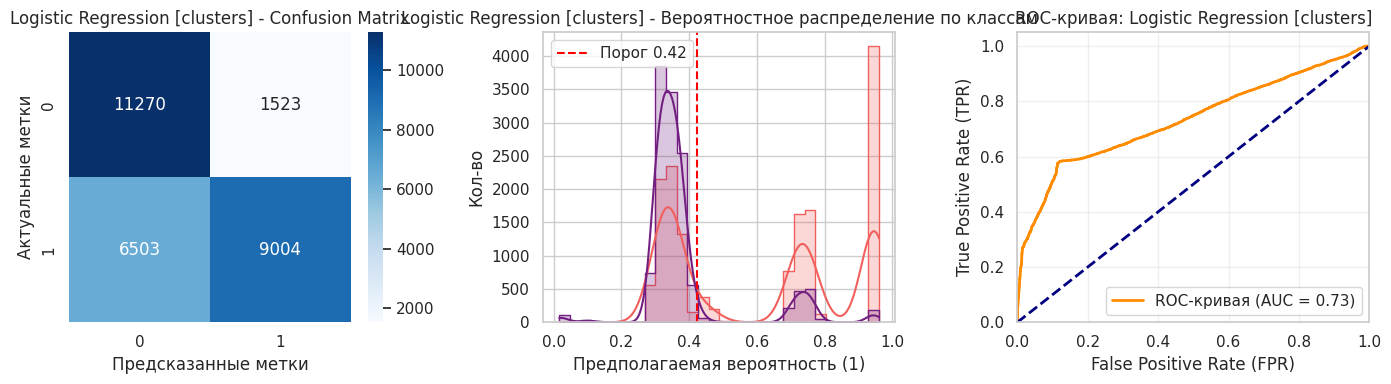

,name,roc_auc,threshold
0,Logistic Regression [clusters],0.73,0.42


In [47]:
lr_best_params, lr_threshold = \
    run_log_reg(
        "Logistic Regression [clusters]",
        upd_X_train, y_train,
        upd_X_val, y_val,
        num_cols, 
        cat_col_ohe + clusters, 
        cat_col_target
    )

Кластеры добавлены как числовые признаки, но номер кластера не несёт порядкового смысла. Стоит передать их как категорильные фичи

In [48]:
final_features = selected_features + clusters

[I 2026-04-20 19:48:31,256] A new study created in memory with name: no-name-2245f8e2-57b7-44c8-be8c-55f0294aa7a8


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-20 19:48:35,684] Trial 0 finished with value: 0.7588658530698075 and parameters: {'iterations': 62, 'depth': 8, 'learning_rate': 0.05395030966670229, 'l2_leaf_reg': 3.968793330444372}. Best is trial 0 with value: 0.7588658530698075.
[I 2026-04-20 19:48:37,115] Trial 1 finished with value: 0.7440835944558031 and parameters: {'iterations': 31, 'depth': 3, 'learning_rate': 0.011430983876313222, 'l2_leaf_reg': 7.348118405270449}. Best is trial 0 with value: 0.7588658530698075.
[I 2026-04-20 19:48:45,589] Trial 2 finished with value: 0.7615783349186913 and parameters: {'iterations': 94, 'depth': 7, 'learning_rate': 0.010485387725194618, 'l2_leaf_reg': 9.330606024425668}. Best is trial 2 with value: 0.7615783349186913.
[I 2026-04-20 19:48:51,168] Trial 3 finished with value: 0.7595286759520192 and parameters: {'iterations': 127, 'depth': 4, 'learning_rate': 0.015199348301309814, 'l2_leaf_reg': 1.5254729458052607}. Best is trial 2 with value: 0.7615783349186913.
[I 2026-04-20 19:48

Лучшие гиперпараметры: {'iterations': 114, 'depth': 4, 'learning_rate': 0.07804568594165359, 'l2_leaf_reg': 9.908696623769005}
Лучшее значение roc_auc на валидационной выборке: 0.7658477774674155
Итоговые метрики:
              precision    recall  f1-score   support

           0       0.64      0.89      0.74     12793
           1       0.86      0.58      0.70     15507

    accuracy                           0.72     28300
   macro avg       0.75      0.73      0.72     28300
weighted avg       0.76      0.72      0.72     28300



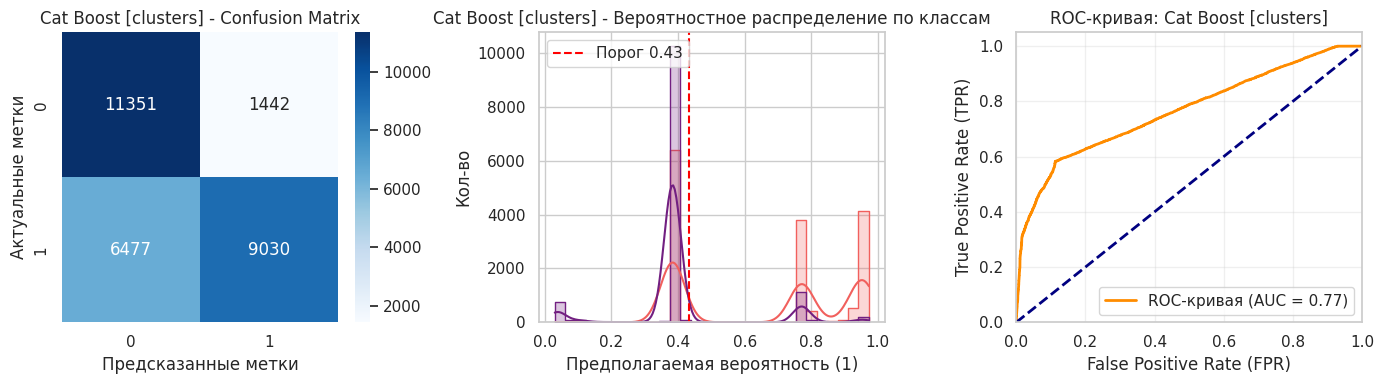

,name,roc_auc,threshold
0,Cat Boost [clusters],0.77,0.43


In [49]:
cb_best_params, cb_threshold = \
    run_catboost(
        "Cat Boost [clusters]",
        upd_X_train, y_train,
        upd_X_val, y_val,
        cb_fixed_params,
        final_features,
        cat_col_ohe + cat_col_target + clusters
    )

In [50]:
show_results(results)

,name,roc_auc,threshold
3,Cat Boost [clusters],0.7658,0.4330
1,Cat Boost [baseline],0.7602,0.5909
2,Logistic Regression [clusters],0.7338,0.4220
0,Logistic Regression [baseline],0.7301,0.4678


В ходе работы были обучены логистическая регрессия и CatBoost в двух вариантах - baseline и с кластерными признаками. Лучший результат показал CatBoost с кластеризацией - ROC-AUC 0.7658, что превышает целевой порог 0.75. Гипотеза о полезности профилирования клиентов частично подтвердилась: кластеры дали небольшой прирост для CatBoost, но не улучшили логистическую регрессию.

---

## Тестирование лучшей модели

Итоговые метрики:
              precision    recall  f1-score   support

           0       0.64      0.89      0.75     16437
           1       0.86      0.58      0.70     19575

    accuracy                           0.72     36012
   macro avg       0.75      0.74      0.72     36012
weighted avg       0.76      0.72      0.72     36012



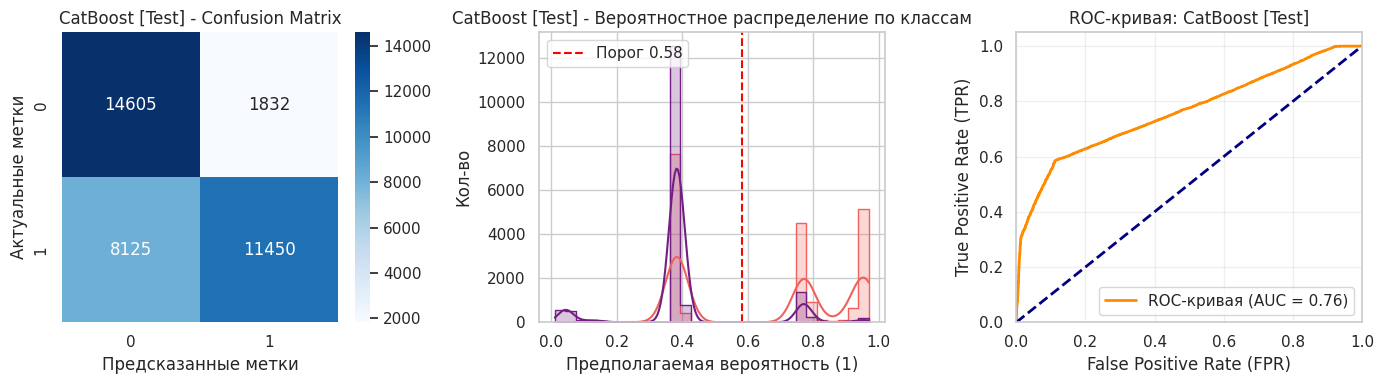

,name,roc_auc,threshold
0,CatBoost [Test],0.76,0.58


In [51]:
X_train_val = pd.concat([upd_X_train, upd_X_val])
y_train_val = pd.concat([y_train, y_val])

model = CatBoostClassifier(**cb_best_params, **cb_fixed_params)
fit_params = {
    'cat_features': cat_col_ohe + cat_col_target + clusters
}

threshold =  evaluate_model(model, X_train_val[final_features], y_train_val, upd_X_test[final_features], y_test, "CatBoost [Test]", fit_params)

In [52]:
def show_model_analysis(model, X_test, y_pred, fit_params):
    feature_importance = pd.DataFrame({
        "Признак": X_test.columns.tolist(),
        "Важность": model.feature_importances_,
    }).sort_values("Важность", ascending=False)

    display(feature_importance.head(10)
            .style.format({'Важность': '{:.4f}'})
            .background_gradient(cmap='coolwarm'))

    top_5 = feature_importance.head(5)
    plt.figure(figsize=(8, 5))
    plt.barh(top_5['Признак'], top_5['Важность'], color='lightseagreen')
    plt.xlabel('Важность признака')
    plt.title('Важность признаков')
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()
    
    pool = Pool(
        X_test,
        **fit_params
    )

    explainer = TreeExplainer(model)
    shap_values = explainer.shap_values(pool)

    summary_plot(shap_values, X_test, plot_size=(16, 8), show=True)
    summary_plot(shap_values, X_test, plot_type="bar", plot_size=(16, 8), show=True)
    force_plot(
        explainer.expected_value,
        shap_values[0],
        X_test.iloc[0],
        matplotlib=True,
        show=True
    )
    waterfall_plot(
        Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=X_test.iloc[0],
            feature_names=X_test.columns.tolist()
        ),
        max_display=10,
        show=False
    )
    plt.title(
        f"Waterfall plot для объекта 0\nПредсказание: {y_pred[0]:.0f}, Фактическое: {y_test.iloc[0]:.0f}",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

,Признак,Важность
4,shipping_mode,70.7079
3,order_hour,25.4496
7,beh_cluster,3.1225
5,category_name,0.2116
1,order_month,0.2070
2,order_weekday,0.1621
6,geo_cluster,0.1014
0,item_price,0.0379


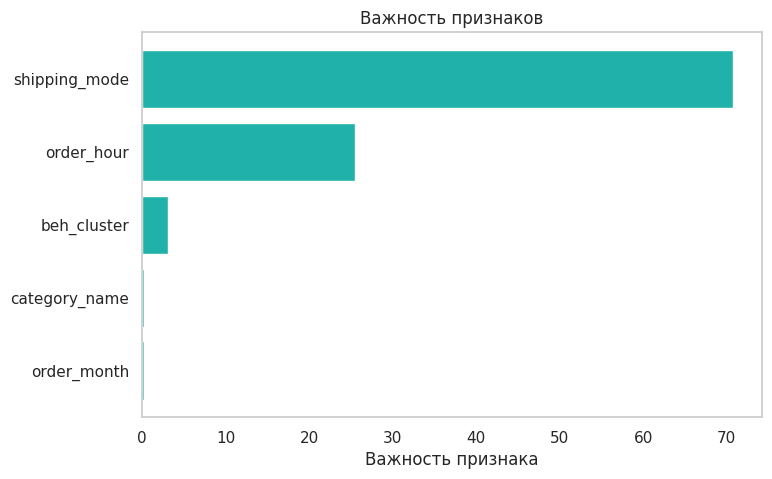

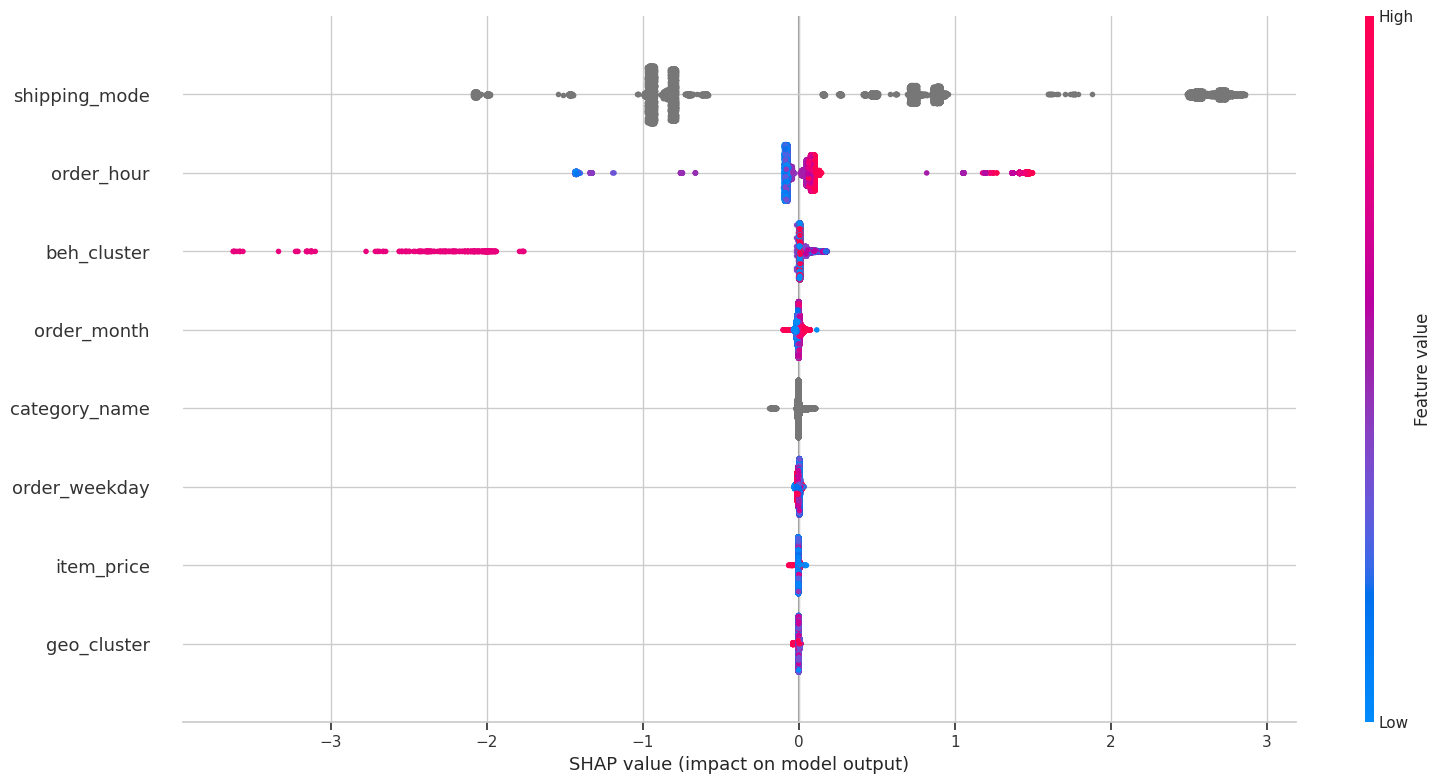

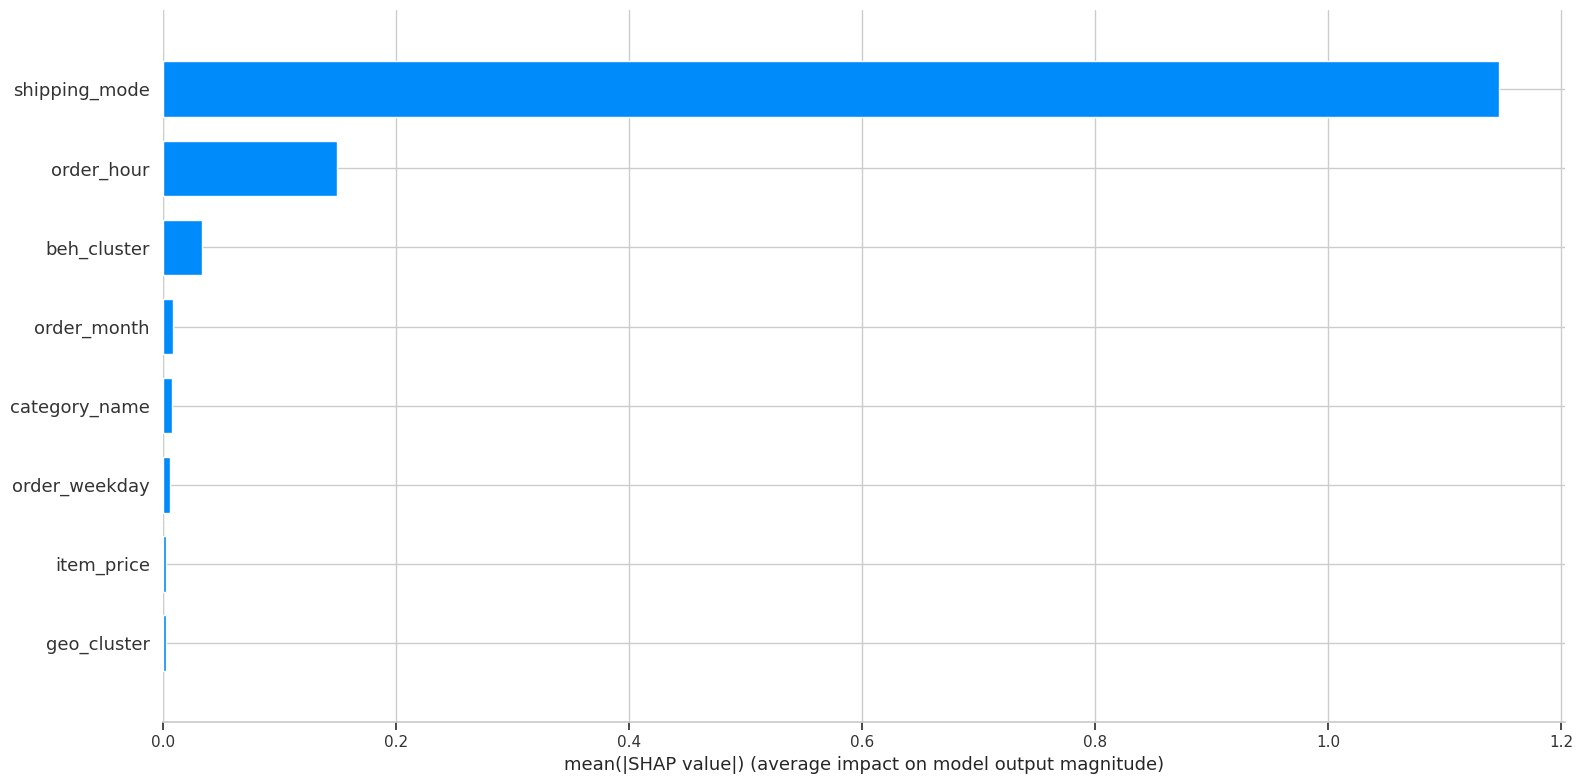

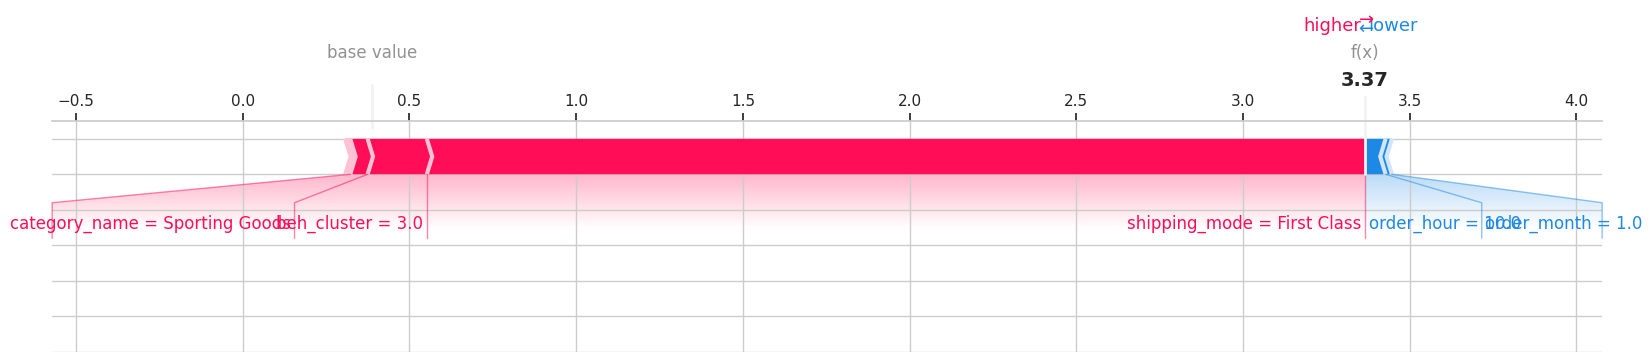

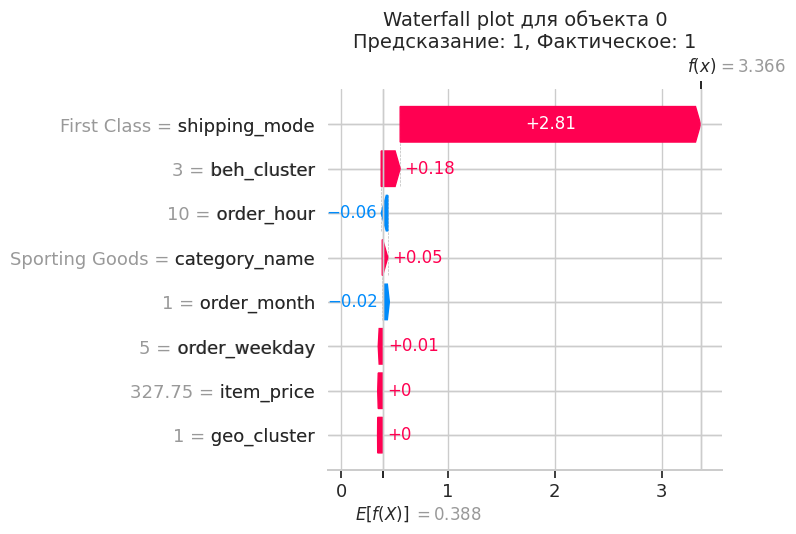

In [53]:
model.fit(X_train_val[final_features], y_train_val, **fit_params)

y_proba_test = model.predict_proba(upd_X_test[final_features])[:, 1]
y_pred = (y_proba_test >= threshold).astype(int)

show_model_analysis(model, upd_X_test[final_features], y_pred, fit_params)

По результатам тестирования модель CatBoost достигла ROC-AUC 0.76 на тестовой выборке, превысив целевой порог 0.75. Анализ важности признаков подтвердил доминирующую роль `shipping_mode` (71) - способ доставки является главным предиктором задержки. На втором месте `order_hour` (25), из кластерных признаков значимым оказался только `beh_cluster` (3), тогда как `geo_cluster` практически не влияет на предсказание. SHAP-анализ для объекта 0 показывает, что `shipping_mode = First Class` даёт вклад +1.5 в предсказание, что полностью определяет итоговый результат. Модель корректно классифицировала объект - предсказание совпало с фактическим значением.

---

### Фиксирование итоговой модели


In [54]:
model_file_name = './model.joblib'

metadata = {
    'model_version': '1.0.0',
    'training_date': '2026-04-19',
    'threshold': threshold,
    'params': { **cb_best_params, **cb_fixed_params },
    'fit_params': fit_params,
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__
}

joblib.dump({
    'pipeline': model,
    'metadata': metadata,
}, model_file_name)

print(f"Объект сохранён в файл {model_file_name}") 

Объект сохранён в файл ./model.joblib


---

## Выводы и рекомендации для бизнеса

В ходе работы были обучены логистическая регрессия и CatBoost в двух вариантах - без кластеризации и с ней. Лучший результат показал CatBoost с поведенческими и географическими кластерами - ROC-AUC 0.76 на тестовой выборке, что превышает целевой порог 0.75.

CatBoost превзошёл логистическую регрессию на ~0.034, что подтверждает преимущество градиентного бустинга на данной задаче - он способен улавливать нелинейные зависимости, которые линейная модель упускает.

Эффективность сегментации
- Гипотеза о полезности профилирования клиентов подтвердилась частично. Поведенческая кластеризация (beh_cluster) вошла в топ-3 важных признаков с весом 2.77 и отрицательным SHAP-вкладом для ряда сегментов, что говорит о реальном влиянии профиля клиента на риск задержки. Географическая кластеризация (geo_cluster) оказалась неинформативной - её важность близка к нулю как по feature_importances_, так и по SHAP. Это означает, что регион доставки сам по себе не определяет риск задержки - важнее то, как и когда клиент делает заказ.

- Из RFM-анализа выделены четыре ключевых сегмента: "Уходящие" (recency 646 дня), "Новички" (1 заказ, минимальная выручка), "Активные VIP" (7+ заказов, выручка 4152) и "Проблемные" (return_rate 0.92). Последний сегмент представляет наибольший операционный риск.

Среди клиентских сегментов наибольший операционный риск представляют "Проблемные" клиенты с `return_rate` близким к 1.0 - их заказы стоит автоматически выделять на дополнительную проверку на этапе оформления. В целом модель готова к внедрению в качестве инструмента скоринга заказов в реальном времени, позволяя диспетчерам заблаговременно реагировать на высокорисковые отправления.

Внедрить модель как инструмент скоринга заказов в реальном времени. При поступлении нового заказа модель за доли секунды выдаёт вероятность задержки - это позволяет диспетчерам оперативно перераспределять ресурсы и приоритизировать высокорисковые заказы до отправки.